# Step A — Project Configuration (Minimal Inputs)

## What we are doing
We define a minimal configuration for the pipeline and automatically set up output folders.

## Why we are doing it
To keep the pipeline fully automated, we only provide essential inputs (dataset location + evaluation target).
Everything else (preprocessing, balancing, feature engineering, feature selection, AutoML) will be automated.

## Tools used
- Python `os`, `pathlib` for portable file paths
- Standard project folder conventions (`data/`, `outputs/`)

## Output of this step
- Output folders created (models, metrics, leaderboards, features)
- Reproducibility seed defined


In [1]:
import os
from pathlib import Path
import json
import pandas as pd
import numpy as np

# Reproducibility
SEED = 42

# Paths (notebook lives in AutoML/notebooks/)
PROJECT_ROOT = Path("..").resolve()
DATA_DIR = (PROJECT_ROOT / "data").resolve()
OUTPUT_DIR = (PROJECT_ROOT / "outputs").resolve()

# Create clean output structure
(OUTPUT_DIR / "models").mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "metrics").mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "leaderboards").mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "features").mkdir(parents=True, exist_ok=True)

print("✅ PROJECT_ROOT:", PROJECT_ROOT)
print("✅ DATA_DIR     :", DATA_DIR)
print("✅ OUTPUT_DIR   :", OUTPUT_DIR)
print("✅ SEED         :", SEED)


✅ PROJECT_ROOT: C:\Users\sohib\Documents\Final Year Project\AutoML
✅ DATA_DIR     : C:\Users\sohib\Documents\Final Year Project\AutoML\data
✅ OUTPUT_DIR   : C:\Users\sohib\Documents\Final Year Project\AutoML\outputs
✅ SEED         : 42


---
# Step B — Automatic Data Discovery and Loading (UNSW-NB15)

## What we are doing
We automatically locate and load the UNSW-NB15 training and testing CSV files from the project folder.

## Why we are doing it
A fully automated pipeline should not rely on hard-coded file paths.
By discovering files automatically, the notebook becomes reproducible and portable.

## Tools used
- Python `pathlib` to search for files
- Pandas to load CSV data

## Output of this step
- `train_df`, `test_df` loaded successfully
- Basic dataset overview (shapes + column check)


In [2]:
# Auto-find UNSW-NB15 files inside AutoML/data/
# Your structure: data/raw/UNSW_NB15_training-set.csv and data/raw/UNSW_NB15_testing-set.csv

train_candidates = list(DATA_DIR.rglob("*UNSW_NB15*training*set*.csv"))
test_candidates  = list(DATA_DIR.rglob("*UNSW_NB15*testing*set*.csv"))

if len(train_candidates) == 0 or len(test_candidates) == 0:
    raise FileNotFoundError(
        "Could not auto-locate UNSW-NB15 train/test CSV files. "
        "Expected names like UNSW_NB15_training-set.csv and UNSW_NB15_testing-set.csv under AutoML/data/."
    )

# If multiple matches, choose the first deterministically (sorted)
train_path = sorted(train_candidates)[0]
test_path  = sorted(test_candidates)[0]

print("Train file found:", train_path)
print("Test file found :", test_path)

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

print("\nLoaded datasets")
print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

print("\nColumns (first 15):", list(train_df.columns[:15]))
display(train_df.head(3))


Train file found: C:\Users\sohib\Documents\Final Year Project\AutoML\data\raw\UNSW_NB15_training-set.csv
Test file found : C:\Users\sohib\Documents\Final Year Project\AutoML\data\raw\UNSW_NB15_testing-set.csv

Loaded datasets
Train shape: (175341, 45)
Test shape : (82332, 45)

Columns (first 15): ['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss']


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0


---
# Step B.1 — Automatic Target Selection and Leakage Prevention

## What we are doing
1) Automatically select the target column for training/evaluation.
2) Automatically remove non-feature columns that cause leakage:
   - `attack_cat` (secondary label)
   - `id` (identifier)

## Why we are doing it
- AutoML requires a target column for supervised evaluation (Precision/Recall/F1/ROC-AUC/FPR).
- `attack_cat` is a label-like column and would leak attack information into features.
- `id` is an identifier and does not represent meaningful predictive signal.

This is rule-based automation (not manual feature selection).

## Tools used
- Pandas (rule-based column handling)

## Output of this step
- Selected target column stored in `TARGET`
- Clean feature matrices `X_train`, `X_test` with leakage removed


In [3]:
# Automatic target selection:
# Preference order for this project:
# 1) 'label' (binary anomaly label)
# 2) fallback: raise error (we keep it strict for clean research)

if "label" in train_df.columns:
    TARGET = "label"
else:
    raise ValueError("No 'label' column found. Please confirm the dataset columns.")

# Columns that must never be used as features (automated leakage prevention)
LEAKAGE_COLS = []
for col in ["id", "attack_cat"]:
    if col in train_df.columns:
        LEAKAGE_COLS.append(col)

print("TARGET selected:", TARGET)
print("Leakage columns auto-removed:", LEAKAGE_COLS)

# Build X/y (remove TARGET and leakage cols)
drop_cols = [TARGET] + LEAKAGE_COLS

X_train = train_df.drop(columns=drop_cols, errors="ignore")
y_train = train_df[TARGET].copy()

X_test  = test_df.drop(columns=drop_cols, errors="ignore")
y_test  = test_df[TARGET].copy()

print("\nShapes after cleaning:")
print("X_train:", X_train.shape, " y_train:", y_train.shape)
print("X_test :", X_test.shape,  " y_test :", y_test.shape)

print("\nClass distribution (train):")
print(y_train.value_counts())

# Save a quick config snapshot (useful for dissertation/reproducibility)
config_snapshot = {
    "seed": SEED,
    "train_path": str(train_path),
    "test_path": str(test_path),
    "target": TARGET,
    "leakage_cols_removed": LEAKAGE_COLS,
    "train_shape": list(train_df.shape),
    "test_shape": list(test_df.shape),
    "x_train_shape": list(X_train.shape),
    "x_test_shape": list(X_test.shape),
}
with open(OUTPUT_DIR / "metrics" / "run_config.json", "w") as f:
    json.dump(config_snapshot, f, indent=2)

print("\nSaved run_config.json to outputs/metrics/")
# Automatic target selection:
# Preference order for this project:
# 1) 'label' (binary anomaly label)
# 2) fallback: raise error (we keep it strict for clean research)

if "label" in train_df.columns:
    TARGET = "label"
else:
    raise ValueError("No 'label' column found. Please confirm the dataset columns.")

# Columns that must never be used as features (automated leakage prevention)
LEAKAGE_COLS = []
for col in ["id", "attack_cat"]:
    if col in train_df.columns:
        LEAKAGE_COLS.append(col)

print("TARGET selected:", TARGET)
print("Leakage columns auto-removed:", LEAKAGE_COLS)

# Build X/y (remove TARGET and leakage cols)
drop_cols = [TARGET] + LEAKAGE_COLS

X_train = train_df.drop(columns=drop_cols, errors="ignore")
y_train = train_df[TARGET].copy()

X_test  = test_df.drop(columns=drop_cols, errors="ignore")
y_test  = test_df[TARGET].copy()

print("\nShapes after cleaning:")
print("X_train:", X_train.shape, " y_train:", y_train.shape)
print("X_test :", X_test.shape,  " y_test :", y_test.shape)

print("\nClass distribution (train):")
print(y_train.value_counts())

# Save a quick config snapshot (useful for dissertation/reproducibility)
config_snapshot = {
    "seed": SEED,
    "train_path": str(train_path),
    "test_path": str(test_path),
    "target": TARGET,
    "leakage_cols_removed": LEAKAGE_COLS,
    "train_shape": list(train_df.shape),
    "test_shape": list(test_df.shape),
    "x_train_shape": list(X_train.shape),
    "x_test_shape": list(X_test.shape),
}
with open(OUTPUT_DIR / "metrics" / "run_config.json", "w") as f:
    json.dump(config_snapshot, f, indent=2)

print("\nSaved run_config.json to outputs/metrics/")


TARGET selected: label
Leakage columns auto-removed: ['id', 'attack_cat']

Shapes after cleaning:
X_train: (175341, 42)  y_train: (175341,)
X_test : (82332, 42)  y_test : (82332,)

Class distribution (train):
label
1    119341
0     56000
Name: count, dtype: int64

Saved run_config.json to outputs/metrics/
TARGET selected: label
Leakage columns auto-removed: ['id', 'attack_cat']

Shapes after cleaning:
X_train: (175341, 42)  y_train: (175341,)
X_test : (82332, 42)  y_test : (82332,)

Class distribution (train):
label
1    119341
0     56000
Name: count, dtype: int64

Saved run_config.json to outputs/metrics/


---
# Step C — Automated Preprocessing (Detect → Encode → Scale)

## What we are doing
We build an automated preprocessing pipeline that:
1) Detects categorical and numerical features automatically
2) Encodes categorical features using One-Hot Encoding
3) Scales numerical features using StandardScaler
4) Fits preprocessing on training data only, then transforms test data

## Why we are doing it
AutoML performance depends heavily on consistent preprocessing.
To meet the "no manual work" requirement, feature types are detected automatically, and transformations are applied programmatically.

This prevents:
- manual feature selection
- inconsistent encoding between train and test
- data leakage (test data is never used to fit preprocessing)

## Tools used
- Scikit-learn `ColumnTransformer`
- `OneHotEncoder` for categoricals
- `StandardScaler` for numericals

## Output of this step
- Preprocessor object saved for reuse
- Transformed matrices:
  - `X_train_pre`
  - `X_test_pre`
- A generated feature-name list for downstream feature selection and reporting


In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
import joblib

# 1) Automatic feature type detection
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in X_train.columns if c not in cat_cols]

print("Auto-detected feature types")
print("Categorical:", cat_cols)
print("Numerical count:", len(num_cols))

# 2) Build automated preprocessing pipeline
# - OneHotEncoder handles unseen categories safely with handle_unknown="ignore"
# - StandardScaler scales numeric features
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ],
    remainder="drop"
)

# 3) Fit on training only; transform both train and test
X_train_pre = preprocessor.fit_transform(X_train)
X_test_pre = preprocessor.transform(X_test)

print("\nPreprocessing complete")
print("X_train_pre shape:", X_train_pre.shape)
print("X_test_pre shape :", X_test_pre.shape)

# 4) Get final feature names (for audit + dissertation)
ohe = preprocessor.named_transformers_["cat"]
cat_feature_names = []
if len(cat_cols) > 0:
    cat_feature_names = ohe.get_feature_names_out(cat_cols).tolist()

final_feature_names = num_cols + cat_feature_names

print("\nFinal feature count:", len(final_feature_names))
print("Example feature names:", final_feature_names[:15])

# 5) Save preprocessing artifact (reusable transformation)
joblib.dump(preprocessor, OUTPUT_DIR / "models" / "preprocessor.joblib")

# Save feature names for later reporting
with open(OUTPUT_DIR / "features" / "final_feature_names.json", "w") as f:
    json.dump(final_feature_names, f, indent=2)

print("\nSaved preprocessor.joblib and final_feature_names.json")


Auto-detected feature types
Categorical: ['proto', 'service', 'state']
Numerical count: 39

Preprocessing complete
X_train_pre shape: (175341, 194)
X_test_pre shape : (82332, 194)

Final feature count: 194
Example feature names: ['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit']

Saved preprocessor.joblib and final_feature_names.json


---
# Step D — Automatic Class Balancing (SMOTE)

## What we are doing
We automatically check for class imbalance in the training labels and apply SMOTE if imbalance is detected.

Because categorical features were already converted into one-hot encoded numeric features in Step C,
we can apply standard SMOTE safely on the preprocessed matrix.

## Why we are doing it
The UNSW-NB15 dataset is imbalanced (more attacks than normal traffic).
Imbalance can bias the model and reduce detection performance on the minority class.

To keep the pipeline fully automated:
- SMOTE is applied only when imbalance exceeds a defined threshold
- SMOTE is applied ONLY to the training set (no leakage)

## Tools used
- imbalanced-learn `SMOTE`

## Output of this step
- Balanced training data:
  - `X_train_bal`, `y_train_bal`
- Unchanged testing data for fair evaluation


In [5]:
from imblearn.over_sampling import SMOTE

# 1) Automatic imbalance check
class_counts = y_train.value_counts()
majority = class_counts.max()
minority = class_counts.min()
imbalance_ratio = minority / majority  # closer to 1.0 = balanced

print("Class counts:\n", class_counts)
print("\nImbalance ratio (minority/majority):", round(float(imbalance_ratio), 4))

# 2) Rule: apply SMOTE if minority < 0.80 of majority (you can cite this as an automated threshold)
SMOTE_THRESHOLD = 0.80
apply_smote = imbalance_ratio < SMOTE_THRESHOLD

print("\nSMOTE_THRESHOLD:", SMOTE_THRESHOLD)
print("Apply SMOTE?", apply_smote)

if apply_smote:
    smote = SMOTE(random_state=SEED)
    X_train_bal, y_train_bal = smote.fit_resample(X_train_pre, y_train)
    smote_status = "APPLIED"
else:
    X_train_bal, y_train_bal = X_train_pre, y_train
    smote_status = "SKIPPED"

print("\nBalancing step complete —", smote_status)
print("X_train_bal shape:", X_train_bal.shape)
print("y_train_bal distribution:\n", pd.Series(y_train_bal).value_counts())

# Save balancing decision for reproducibility
balancing_info = {
    "smote_threshold": SMOTE_THRESHOLD,
    "imbalance_ratio": float(imbalance_ratio),
    "smote_status": smote_status,
    "before_counts": class_counts.to_dict(),
    "after_counts": pd.Series(y_train_bal).value_counts().to_dict()
}
with open(OUTPUT_DIR / "metrics" / "balancing_info.json", "w") as f:
    json.dump(balancing_info, f, indent=2)

print("\nSaved balancing_info.json to outputs/metrics/")


Class counts:
 label
1    119341
0     56000
Name: count, dtype: int64

Imbalance ratio (minority/majority): 0.4692

SMOTE_THRESHOLD: 0.8
Apply SMOTE? True

Balancing step complete — APPLIED
X_train_bal shape: (238682, 194)
y_train_bal distribution:
 label
0    119341
1    119341
Name: count, dtype: int64

Saved balancing_info.json to outputs/metrics/


---
# Step E — Automated Feature Ranking and Selection (Mutual Information)

## What we are doing

We automatically rank all features based on their importance using Mutual Information.

Mutual Information measures how much information each feature provides about the target variable.

The pipeline then automatically selects the most informative features based on a predefined rule.

## Why we are doing it

Using all features may introduce noise and reduce model performance.

Automated feature selection improves:

- model performance
- training efficiency
- generalisation capability

This process is fully automated and requires no manual feature selection.

## Tools used

- scikit-learn mutual_info_classif

## Output of this step

- Feature importance ranking
- Automatically selected feature subset
- Saved feature ranking file


In [6]:
from sklearn.feature_selection import mutual_info_classif

print("Computing mutual information scores...")

# Compute MI scores automatically
mi_scores = mutual_info_classif(
    X_train_bal,
    y_train_bal,
    random_state=SEED
)

# Convert to DataFrame for ranking
mi_df = pd.DataFrame({
    "feature": final_feature_names,
    "mi_score": mi_scores
}).sort_values("mi_score", ascending=False).reset_index(drop=True)

print("Top 10 features by mutual information:")
display(mi_df.head(10))

# Automated selection rule:
# keep features with MI > median (fully automated threshold)
mi_threshold = mi_df["mi_score"].median()

selected_features = mi_df[mi_df["mi_score"] > mi_threshold]["feature"].tolist()

print("\nMI threshold:", mi_threshold)
print("Selected feature count:", len(selected_features))
print("Original feature count:", len(final_feature_names))

# Get indices of selected features
selected_indices = [final_feature_names.index(f) for f in selected_features]

# Create reduced feature sets
X_train_sel = X_train_bal[:, selected_indices]
X_test_sel  = X_test_pre[:, selected_indices]

print("\nReduced shapes:")
print("X_train_sel:", X_train_sel.shape)
print("X_test_sel :", X_test_sel.shape)

# Save feature ranking
mi_df.to_csv(OUTPUT_DIR / "features" / "mutual_information_ranking.csv", index=False)

# Save selected features list
with open(OUTPUT_DIR / "features" / "selected_features.json", "w") as f:
    json.dump(selected_features, f, indent=2)

print("\nSaved mutual_information_ranking.csv and selected_features.json")


Computing mutual information scores...
Top 10 features by mutual information:


,feature,mi_score
0,sbytes,0.522562
1,smean,0.422430
2,sttl,0.403780
3,sload,0.396694
4,rate,0.392049
5,dbytes,0.378052
6,ct_state_ttl,0.377356
7,dur,0.374907
8,dttl,0.368912
9,dmean,0.356656



MI threshold: 0.0008903087265254017
Selected feature count: 97
Original feature count: 194

Reduced shapes:
X_train_sel: (238682, 97)
X_test_sel : (82332, 97)

Saved mutual_information_ranking.csv and selected_features.json


---
# Step F — Fully Automated Model Training using H2O AutoML

## What we are doing

We run H2O AutoML on the automatically selected feature set.

AutoML will:

- train multiple machine learning algorithms
- tune hyperparameters automatically
- compare models
- select the best performing model

## Why we are doing it

Manual model selection is time-consuming and subjective.

AutoML ensures:

- optimal model selection
- automated hyperparameter tuning
- reproducible and efficient model development

## Tools used

- H2O AutoML

## Output of this step

- AutoML leaderboard
- Best model automatically selected
- Saved model artifact
- Evaluation metrics


In [7]:
import h2o
from h2o.automl import H2OAutoML

# Initialize H2O if not already running
try:
    h2o.cluster_info()
except:
    h2o.init()

# Convert selected feature sets to H2OFrames
train_sel_df = pd.DataFrame(X_train_sel, columns=selected_features)
train_sel_df[TARGET] = y_train_bal.values

test_sel_df = pd.DataFrame(X_test_sel, columns=selected_features)
test_sel_df[TARGET] = y_test.values

train_h2o = h2o.H2OFrame(train_sel_df)
test_h2o  = h2o.H2OFrame(test_sel_df)

# Convert target to factor (classification)
train_h2o[TARGET] = train_h2o[TARGET].asfactor()
test_h2o[TARGET]  = test_h2o[TARGET].asfactor()

print("H2O training shape:", train_h2o.shape)
print("H2O testing shape :", test_h2o.shape)

# Define features automatically
feature_cols = [col for col in train_h2o.columns if col != TARGET]

# Run AutoML (fully automated)
aml = H2OAutoML(
    seed=SEED,
    max_runtime_secs=1800,   # 30 minutes (you can reduce to 600 for testing)
    max_models=20,
    sort_metric="AUC"
)

print("\nStarting AutoML training...")
aml.train(
    x=feature_cols,
    y=TARGET,
    training_frame=train_h2o
)

print("\nAutoML training complete")

# Leaderboard
leaderboard = aml.leaderboard.as_data_frame()

display(leaderboard.head(10))

# Save leaderboard
leaderboard.to_csv(OUTPUT_DIR / "leaderboards" / "automl_leaderboard.csv", index=False)

# Best model
leader = aml.leader

print("\nBest model selected:", leader.model_id)

# Save best model
model_path = h2o.save_model(
    model=leader,
    path=str(OUTPUT_DIR / "models"),
    force=True
)

print("Best model saved to:", model_path)

# Evaluate on test set
perf = leader.model_performance(test_h2o)

metrics = {
    "AUC": perf.auc(),
    "Precision": perf.precision()[0][1],
    "Recall": perf.recall()[0][1],
    "F1": perf.F1()[0][1]
}

print("\nTest metrics:", metrics)

# Save metrics
with open(OUTPUT_DIR / "metrics" / "test_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("\nSaved leaderboard, model, and metrics")


Checking whether there is an H2O instance running at http://localhost:54321.

C:\Users\sohib\AppData\Local\Temp\ipykernel_17708\3137658290.py:6: H2ODeprecationWarning: Deprecated, use ``h2o.cluster().show_status()``.
  h2o.cluster_info()


 connected.


H2O_cluster_uptime:,1 hour 53 mins
H2O_cluster_timezone:,Europe/London
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.9
H2O_cluster_version_age:,2 months and 20 days
H2O_cluster_name:,H2O_from_python_sohib_0caiiv
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.840 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
H2O training shape: (238682, 98)
H2O testing shape : (82332, 98)

Starting AutoML training...
AutoML progress: |█
18:12:54.151: AutoML: XGBoost is not available; skipping it.

██████████████████████████████████████████████████████████████| (done) 100%

AutoML training complete


C:\Users\sohib\anaconda3\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


,model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse
0,GBM_1_AutoML_1_20260213_181254,0.996879,0.072156,0.996882,0.031142,0.149601,0.022381
1,GBM_3_AutoML_1_20260213_181254,0.996854,0.073060,0.996850,0.031339,0.149798,0.022439
2,GBM_2_AutoML_1_20260213_181254,0.996668,0.075102,0.996653,0.032675,0.152048,0.023119
3,DRF_1_AutoML_1_20260213_181254,0.996028,0.091195,0.996039,0.036433,0.164740,0.027139
4,GLM_1_AutoML_1_20260213_181254,0.982666,0.165646,0.982146,0.077170,0.230243,0.053012



Best model selected: GBM_1_AutoML_1_20260213_181254
Best model saved to: C:\Users\sohib\Documents\Final Year Project\AutoML\outputs\models\GBM_1_AutoML_1_20260213_181254

Test metrics: {'AUC': 0.9846041991099898, 'Precision': 1.0, 'Recall': 1.0, 'F1': 0.9364979140827602}

Saved leaderboard, model, and metrics


---
## Step F.1 — Ensuring Reproducible AutoML Algorithms (XGBoost Handling)

In some Windows environments, H2O AutoML may skip XGBoost due to runtime/platform constraints.
To ensure reproducibility and remove algorithm availability variability, XGBoost is explicitly excluded.

This keeps the AutoML search consistent across reruns and avoids "skipped" training messages.


In [ ]:
# i can run this code for clean look but for now i dont need it
aml = H2OAutoML(
    seed=SEED,
    max_runtime_secs=1800,
    max_models=20,
    sort_metric="AUC",
    exclude_algos=["XGBoost"]  # explicit, clean
)


---
## Step F.2 — Automated Threshold Selection for Metrics (Best-F1)

Classification metrics such as Precision, Recall, and F1 depend on the decision threshold.
To avoid reporting a threshold-dependent value from an arbitrary row, we automatically select the threshold that maximises F1.

This produces valid and reproducible evaluation metrics for the test set.


In [8]:
# Recompute metrics at the best-F1 threshold (automatic, no manual thresholding)

perf = leader.model_performance(test_h2o)

best_thr = perf.find_threshold_by_max_metric("f1")
f1_at = perf.F1(thresholds=[best_thr])[0][1]
prec_at = perf.precision(thresholds=[best_thr])[0][1]
rec_at = perf.recall(thresholds=[best_thr])[0][1]
auc = perf.auc()
aucpr = perf.aucpr()

# False Positive Rate at best F1 threshold
# (H2O gives FPR = 1 - specificity)
spec_at = perf.specificity(thresholds=[best_thr])[0][1]
fpr_at = 1.0 - spec_at

fixed_metrics = {
    "AUC": float(auc),
    "AUCPR": float(aucpr),
    "best_f1_threshold": float(best_thr),
    "Precision_at_bestF1": float(prec_at),
    "Recall_at_bestF1": float(rec_at),
    "F1_at_bestF1": float(f1_at),
    "FPR_at_bestF1": float(fpr_at)
}

print("Metrics at best-F1 threshold:")
print(fixed_metrics)

with open(OUTPUT_DIR / "metrics" / "test_metrics_bestF1.json", "w") as f:
    json.dump(fixed_metrics, f, indent=2)

print("\nSaved test_metrics_bestF1.json to outputs/metrics/")


Metrics at best-F1 threshold:
{'AUC': 0.9846041991099898, 'AUCPR': 0.9886558201621676, 'best_f1_threshold': 0.875211908812319, 'Precision_at_bestF1': 0.9578163199409567, 'Recall_at_bestF1': 0.9161078267007853, 'F1_at_bestF1': 0.9364979140827602, 'FPR_at_bestF1': 0.04943243243243245}

Saved test_metrics_bestF1.json to outputs/metrics/


---
# Step G — Automated Feature Transformation Experiment (PCA → AutoML)

## What we are doing
We generate a PCA-based feature representation automatically from the preprocessed feature matrix, then train H2O AutoML on the PCA features.

## Why we are doing it
The TOR requires unsupervised representation learning (e.g., PCA) to create alternative feature sets that may capture more meaningful structure in network traffic.

This step is fully automated:
- PCA dimensionality is chosen automatically using an explained-variance rule
- No manual feature selection is performed
- AutoML selects the best model automatically

## Tools used
- scikit-learn PCA
- H2O AutoML

## Output of this step
- PCA transformation artifact
- AutoML leaderboard and best model trained on PCA features
- Saved metrics for comparison with the baseline feature set


In [9]:
from sklearn.decomposition import PCA
import joblib

# 1) Automatic PCA dimension selection by explained variance
# Rule: keep enough components to explain 95% variance (fully automatic)
pca = PCA(n_components=0.95, random_state=SEED)

X_train_pca = pca.fit_transform(X_train_bal)
X_test_pca  = pca.transform(X_test_pre)

print("✅ PCA complete")
print("Original dims:", X_train_bal.shape[1])
print("PCA dims     :", X_train_pca.shape[1])
print("Explained variance:", round(float(np.sum(pca.explained_variance_ratio_)), 4))

# Save PCA artifact
joblib.dump(pca, OUTPUT_DIR / "models" / "pca_95.joblib")

# 2) Convert PCA features to H2OFrames for AutoML
pca_feature_cols = [f"PC{i+1}" for i in range(X_train_pca.shape[1])]

train_pca_df = pd.DataFrame(X_train_pca, columns=pca_feature_cols)
train_pca_df[TARGET] = y_train_bal.values

test_pca_df = pd.DataFrame(X_test_pca, columns=pca_feature_cols)
test_pca_df[TARGET] = y_test.values

train_pca_h2o = h2o.H2OFrame(train_pca_df)
test_pca_h2o  = h2o.H2OFrame(test_pca_df)

train_pca_h2o[TARGET] = train_pca_h2o[TARGET].asfactor()
test_pca_h2o[TARGET]  = test_pca_h2o[TARGET].asfactor()

# 3) AutoML on PCA features (explicitly exclude XGBoost for clean reproducibility)
aml_pca = H2OAutoML(
    seed=SEED,
    max_runtime_secs=1800,
    max_models=20,
    sort_metric="AUC",
    exclude_algos=["XGBoost"]
)

print("\nStarting AutoML (PCA features)...")
aml_pca.train(x=pca_feature_cols, y=TARGET, training_frame=train_pca_h2o)
print("✅ AutoML (PCA) complete")

# Leaderboard + save
lb_pca = aml_pca.leaderboard.as_data_frame()
lb_pca.to_csv(OUTPUT_DIR / "leaderboards" / "automl_leaderboard_pca.csv", index=False)

leader_pca = aml_pca.leader
perf_pca = leader_pca.model_performance(test_pca_h2o)

best_thr_pca = perf_pca.find_threshold_by_max_metric("f1")
metrics_pca = {
    "AUC": float(perf_pca.auc()),
    "AUCPR": float(perf_pca.aucpr()),
    "best_f1_threshold": float(best_thr_pca),
    "Precision_at_bestF1": float(perf_pca.precision(thresholds=[best_thr_pca])[0][1]),
    "Recall_at_bestF1": float(perf_pca.recall(thresholds=[best_thr_pca])[0][1]),
    "F1_at_bestF1": float(perf_pca.F1(thresholds=[best_thr_pca])[0][1]),
    "FPR_at_bestF1": float(1.0 - perf_pca.specificity(thresholds=[best_thr_pca])[0][1]),
    "leader_model_id": leader_pca.model_id,
    "pca_components": int(X_train_pca.shape[1]),
    "pca_explained_variance": float(np.sum(pca.explained_variance_ratio_))
}

with open(OUTPUT_DIR / "metrics" / "test_metrics_pca_bestF1.json", "w") as f:
    json.dump(metrics_pca, f, indent=2)

print("\n✅ PCA leader:", leader_pca.model_id)
print("✅ PCA metrics:", metrics_pca)


✅ PCA complete
Original dims: 194
PCA dims     : 22
Explained variance: 0.9553
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%

Starting AutoML (PCA features)...
AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%
✅ AutoML (PCA) complete


C:\Users\sohib\anaconda3\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"



✅ PCA leader: GBM_grid_1_AutoML_2_20260213_185958_model_3
✅ PCA metrics: {'AUC': 0.9679808294242358, 'AUCPR': 0.9757833575952035, 'best_f1_threshold': 0.9079033094776585, 'Precision_at_bestF1': 0.9337706155770003, 'Recall_at_bestF1': 0.8730256772258007, 'F1_at_bestF1': 0.9023770164738072, 'FPR_at_bestF1': 0.07586486486486488, 'leader_model_id': 'GBM_grid_1_AutoML_2_20260213_185958_model_3', 'pca_components': 22, 'pca_explained_variance': 0.9553319171870502}


---
## Step G.1 — Baseline vs PCA Performance Comparison

This section compares the baseline feature-centric pipeline against the PCA representation.
Metrics are reported at the automatically selected best-F1 threshold.


In [10]:
# Load baseline metrics (bestF1) and PCA metrics from files
import json

with open(OUTPUT_DIR / "metrics" / "test_metrics_bestF1.json", "r") as f:
    baseline = json.load(f)

with open(OUTPUT_DIR / "metrics" / "test_metrics_pca_bestF1.json", "r") as f:
    pca_m = json.load(f)

comparison = pd.DataFrame([
    {"Run": "Baseline_MI_Selected", **baseline},
    {"Run": "PCA_95_Variance", **pca_m},
])

# Keep key columns (safe if some keys missing)
cols = ["Run", "AUC", "AUCPR", "Precision_at_bestF1", "Recall_at_bestF1", "F1_at_bestF1", "FPR_at_bestF1"]
comparison = comparison[[c for c in cols if c in comparison.columns]]

display(comparison)

comparison.to_csv(OUTPUT_DIR / "metrics" / "comparison_baseline_vs_pca.csv", index=False)
print("Saved comparison_baseline_vs_pca.csv to outputs/metrics/")


,Run,AUC,AUCPR,Precision_at_bestF1,Recall_at_bestF1,F1_at_bestF1,FPR_at_bestF1
0,Baseline_MI_Selected,0.984604,0.988656,0.957816,0.916108,0.936498,0.049432
1,PCA_95_Variance,0.967981,0.975783,0.933771,0.873026,0.902377,0.075865


Saved comparison_baseline_vs_pca.csv to outputs/metrics/


---
# Step H — Unsupervised Representation Learning (Autoencoder) → AutoML

## What we are doing
1) Train an **unsupervised autoencoder** on the preprocessed feature matrix (no labels used).
2) Extract **latent (deep) features** from the bottleneck layer.
3) Train **H2O AutoML** using only the latent features to evaluate anomaly detection performance.

## Why we are doing it
The TOR requires using autoencoders to generate latent feature sets that may capture non-linear structure in network traffic better than PCA.

This is fully automated:
- Autoencoder architecture is selected by a rule based on input dimension
- Latent features are extracted programmatically
- AutoML performs automatic model selection and tuning

## Tools used
- H2O DeepLearning (Autoencoder mode)
- H2O AutoML

## Output of this step
- Latent feature dataset
- AutoML leaderboard trained on latent features
- Best model and evaluation metrics saved for comparison


In [11]:
from h2o.estimators.deeplearning import H2ODeepLearningEstimator
from h2o.automl import H2OAutoML
import numpy as np
import pandas as pd
import json

# -----------------------------
# H.0 Prepare UNSUPERVISED input
# -----------------------------
# IMPORTANT: autoencoder training should NOT use SMOTE data (SMOTE changes feature distribution).
# So we train the autoencoder on X_train_pre (original preprocessed training), without labels.

X_train_pre_df = pd.DataFrame(X_train_pre, columns=final_feature_names)
X_test_pre_df  = pd.DataFrame(X_test_pre,  columns=final_feature_names)

train_ae_h2o = h2o.H2OFrame(X_train_pre_df)
test_ae_h2o  = h2o.H2OFrame(X_test_pre_df)

input_dim = X_train_pre.shape[1]

# -----------------------------
# H.1 Automated architecture rule
# -----------------------------
# Latent size rule: keep it compact but not too small
latent_dim = int(min(32, max(8, input_dim // 8)))

# Symmetric autoencoder: [2*latent, latent, 2*latent]
hidden_1 = int(max(16, 2 * latent_dim))
hidden = [hidden_1, latent_dim, hidden_1]

print("Autoencoder architecture (automated):")
print("input_dim =", input_dim, " latent_dim =", latent_dim, " hidden =", hidden)

# -----------------------------
# H.2 Train H2O Autoencoder (UNSUPERVISED)
# -----------------------------
ae = H2ODeepLearningEstimator(
    autoencoder=True,
    hidden=hidden,
    activation="Tanh",
    epochs=10,              # keep modest; you can raise later (still automated)
    seed=SEED,
    reproducible=True,
    ignore_const_cols=True
)

print("\nTraining autoencoder (unsupervised)...")
ae.train(x=train_ae_h2o.columns, training_frame=train_ae_h2o)
print("Autoencoder training complete")

# -----------------------------
# H.3 Extract latent (deep) features automatically
# -----------------------------
# deepfeatures returns the activations from a chosen hidden layer index (1-based in H2O docs).
# Our bottleneck is the middle layer => index 2 for [hidden1, latent, hidden1]
bottleneck_layer_index = 2

train_latent = ae.deepfeatures(train_ae_h2o, layer=bottleneck_layer_index)
test_latent  = ae.deepfeatures(test_ae_h2o,  layer=bottleneck_layer_index)

latent_cols = [f"AE{i+1}" for i in range(train_latent.shape[1])]
train_latent.set_names(latent_cols)
test_latent.set_names(latent_cols)

print("\nLatent feature shapes:")
print("train_latent:", train_latent.shape)
print("test_latent :", test_latent.shape)

# -----------------------------
# H.4 Attach labels for SUPERVISED evaluation/AutoML
# -----------------------------
# Use SMOTE-balanced labels for training AutoML (supervisor wants SMOTE tool used automatically).
# For latent features, we balance by applying SMOTE on latent matrix (already numeric).
# We'll reuse y_train_bal (balanced labels) but we need balanced latent training data too.

# Convert latent to numpy/pandas
train_latent_pd = train_latent.as_data_frame()
test_latent_pd  = test_latent.as_data_frame()

from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=SEED)
X_lat_bal, y_lat_bal = sm.fit_resample(train_latent_pd.values, y_train.values)  # balance based on original y_train

X_lat_bal_df = pd.DataFrame(X_lat_bal, columns=latent_cols)
X_lat_bal_df[TARGET] = y_lat_bal.values

test_lat_df = test_latent_pd.copy()
test_lat_df[TARGET] = y_test.values

train_lat_h2o = h2o.H2OFrame(X_lat_bal_df)
test_lat_h2o  = h2o.H2OFrame(test_lat_df)

train_lat_h2o[TARGET] = train_lat_h2o[TARGET].asfactor()
test_lat_h2o[TARGET]  = test_lat_h2o[TARGET].asfactor()

# -----------------------------
# H.5 AutoML on latent features (exclude XGBoost for clean reproducibility)
# -----------------------------
aml_ae = H2OAutoML(
    seed=SEED,
    max_runtime_secs=1800,
    max_models=20,
    sort_metric="AUC",
    exclude_algos=["XGBoost"]
)

print("\nStarting AutoML (Autoencoder latent features)...")
aml_ae.train(x=latent_cols, y=TARGET, training_frame=train_lat_h2o)
print("AutoML (Autoencoder) complete")

lb_ae = aml_ae.leaderboard.as_data_frame()
lb_ae.to_csv(OUTPUT_DIR / "leaderboards" / "automl_leaderboard_autoencoder.csv", index=False)

leader_ae = aml_ae.leader
perf_ae = leader_ae.model_performance(test_lat_h2o)

best_thr_ae = perf_ae.find_threshold_by_max_metric("f1")
metrics_ae = {
    "AUC": float(perf_ae.auc()),
    "AUCPR": float(perf_ae.aucpr()),
    "best_f1_threshold": float(best_thr_ae),
    "Precision_at_bestF1": float(perf_ae.precision(thresholds=[best_thr_ae])[0][1]),
    "Recall_at_bestF1": float(perf_ae.recall(thresholds=[best_thr_ae])[0][1]),
    "F1_at_bestF1": float(perf_ae.F1(thresholds=[best_thr_ae])[0][1]),
    "FPR_at_bestF1": float(1.0 - perf_ae.specificity(thresholds=[best_thr_ae])[0][1]),
    "leader_model_id": leader_ae.model_id,
    "latent_dim": latent_dim,
    "hidden": hidden,
    "epochs": 10
}

with open(OUTPUT_DIR / "metrics" / "test_metrics_autoencoder_bestF1.json", "w") as f:
    json.dump(metrics_ae, f, indent=2)

print("\nAE leader:", leader_ae.model_id)
print("AE metrics:", metrics_ae)
print("\nSaved: leaderboard + metrics to outputs/")


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Autoencoder architecture (automated):
input_dim = 194  latent_dim = 24  hidden = [48, 24, 48]

Training autoencoder (unsupervised)...
deeplearning Model Build progress: |█████████████████████████████████████████████| (done) 100%
Autoencoder training complete
deepfeatures progress: |█████████████████████████████████████████████████████████| (done) 100%
deepfeatures progress: |█████████████████████████████████████████████████████████| (done) 100%

Latent feature shapes:
train_latent: (175341, 48)
test_latent : (82332, 48)


C:\Users\sohib\anaconda3\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
C:\Users\sohib\anaconda3\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


AttributeError: 'numpy.ndarray' object has no attribute 'values'

In [12]:
from imblearn.over_sampling import SMOTE
from h2o.automl import H2OAutoML
import json
import pandas as pd

# Convert latent features to pandas
train_latent_pd = train_latent.as_data_frame()
test_latent_pd  = test_latent.as_data_frame()

# Apply SMOTE on latent space (numeric, safe)
sm = SMOTE(random_state=SEED)
X_lat_bal, y_lat_bal = sm.fit_resample(train_latent_pd.values, y_train.values)

# Build balanced training dataframe
X_lat_bal_df = pd.DataFrame(X_lat_bal, columns=latent_cols)
X_lat_bal_df[TARGET] = y_lat_bal   # ✅ fixed

# Build test dataframe (unchanged)
test_lat_df = test_latent_pd.copy()
test_lat_df[TARGET] = y_test.values

# Convert to H2O
train_lat_h2o = h2o.H2OFrame(X_lat_bal_df)
test_lat_h2o  = h2o.H2OFrame(test_lat_df)

train_lat_h2o[TARGET] = train_lat_h2o[TARGET].asfactor()
test_lat_h2o[TARGET]  = test_lat_h2o[TARGET].asfactor()

# AutoML on latent features (exclude XGBoost for reproducibility)
aml_ae = H2OAutoML(
    seed=SEED,
    max_runtime_secs=1800,
    max_models=20,
    sort_metric="AUC",
    exclude_algos=["XGBoost"]
)

print("Starting AutoML (Autoencoder latent features)...")
aml_ae.train(x=latent_cols, y=TARGET, training_frame=train_lat_h2o)
print("✅ AutoML (Autoencoder) complete")

# Save leaderboard
lb_ae = aml_ae.leaderboard.as_data_frame()
lb_ae.to_csv(OUTPUT_DIR / "leaderboards" / "automl_leaderboard_autoencoder.csv", index=False)

# Evaluate with best-F1 threshold (automatic)
leader_ae = aml_ae.leader
perf_ae = leader_ae.model_performance(test_lat_h2o)
best_thr_ae = perf_ae.find_threshold_by_max_metric("f1")

metrics_ae = {
    "AUC": float(perf_ae.auc()),
    "AUCPR": float(perf_ae.aucpr()),
    "best_f1_threshold": float(best_thr_ae),
    "Precision_at_bestF1": float(perf_ae.precision(thresholds=[best_thr_ae])[0][1]),
    "Recall_at_bestF1": float(perf_ae.recall(thresholds=[best_thr_ae])[0][1]),
    "F1_at_bestF1": float(perf_ae.F1(thresholds=[best_thr_ae])[0][1]),
    "FPR_at_bestF1": float(1.0 - perf_ae.specificity(thresholds=[best_thr_ae])[0][1]),
    "leader_model_id": leader_ae.model_id,
    "latent_cols": len(latent_cols)
}

with open(OUTPUT_DIR / "metrics" / "test_metrics_autoencoder_bestF1.json", "w") as f:
    json.dump(metrics_ae, f, indent=2)

print("\n✅ AE leader:", leader_ae.model_id)
print("✅ AE metrics:", metrics_ae)
print("\n✅ Saved leaderboard + metrics in outputs/")


C:\Users\sohib\anaconda3\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
C:\Users\sohib\anaconda3\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Starting AutoML (Autoencoder latent features)...
AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%
✅ AutoML (Autoencoder) complete


C:\Users\sohib\anaconda3\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"



✅ AE leader: GBM_4_AutoML_3_20260213_200153
✅ AE metrics: {'AUC': 0.9727014745266752, 'AUCPR': 0.9797455677051569, 'best_f1_threshold': 0.8576607620410224, 'Precision_at_bestF1': 0.938656646312823, 'Recall_at_bestF1': 0.88167299038207, 'F1_at_bestF1': 0.9092729092729094, 'FPR_at_bestF1': 0.0705945945945946, 'leader_model_id': 'GBM_4_AutoML_3_20260213_200153', 'latent_cols': 48}

✅ Saved leaderboard + metrics in outputs/


In [13]:
import importlib
print("TensorFlow installed?", importlib.util.find_spec("tensorflow") is not None)


TensorFlow installed? True


---
# Step I — Unsupervised Representation Learning (VAE) → AutoML

## What we are doing
1) Train a Variational Autoencoder (VAE) on the preprocessed training features **without using labels**.
2) Extract the VAE latent mean vector (z_mean) as a compact learned representation.
3) Balance latent training features automatically (SMOTE in latent space).
4) Run H2O AutoML on the VAE latent features and evaluate using best-F1 threshold metrics.

## Why we are doing it
The TOR requires VAEs as an unsupervised representation learning method to generate latent features that may capture non-linear structure better than PCA.

## Tools used
- TensorFlow / Keras for VAE
- SMOTE for class balancing in latent space (automated)
- H2O AutoML for model selection

## Output of this step
- VAE latent features
- AutoML leaderboard + leader model
- Saved metrics for comparison with baseline/PCA/AE


In [14]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from imblearn.over_sampling import SMOTE
from h2o.automl import H2OAutoML
import json

# -----------------------------
# I.1 Prepare UNSUPERVISED input
# -----------------------------
# Train VAE on original preprocessed training features (NO labels)
X_vae_train = X_train_pre.astype(np.float32)
X_vae_test  = X_test_pre.astype(np.float32)

input_dim = X_vae_train.shape[1]
latent_dim = int(min(32, max(8, input_dim // 8)))  # same rule as AE for fairness

print("VAE config (automated): input_dim =", input_dim, "latent_dim =", latent_dim)

# -----------------------------
# I.2 Build VAE (fully automated architecture)
# -----------------------------
hidden_dim = int(max(64, input_dim // 2))

inputs = keras.Input(shape=(input_dim,), name="x")
h = layers.Dense(hidden_dim, activation="relu")(inputs)
h = layers.Dense(hidden_dim // 2, activation="relu")(h)

z_mean = layers.Dense(latent_dim, name="z_mean")(h)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(h)

def sampling(args):
    z_m, z_lv = args
    eps = tf.random.normal(shape=(tf.shape(z_m)[0], tf.shape(z_m)[1]))
    return z_m + tf.exp(0.5 * z_lv) * eps

z = layers.Lambda(sampling, name="z")([z_mean, z_log_var])

# Decoder
latent_inputs = keras.Input(shape=(latent_dim,), name="z_sampling")
d = layers.Dense(hidden_dim // 2, activation="relu")(latent_inputs)
d = layers.Dense(hidden_dim, activation="relu")(d)
outputs = layers.Dense(input_dim, activation="linear")(d)

encoder = keras.Model(inputs, [z_mean, z_log_var, z], name="encoder")
decoder = keras.Model(latent_inputs, outputs, name="decoder")

# VAE model
vae_outputs = decoder(encoder(inputs)[2])
vae = keras.Model(inputs, vae_outputs, name="vae")

# Loss: reconstruction + KL divergence
recon_loss = tf.reduce_mean(tf.reduce_sum(tf.square(inputs - vae_outputs), axis=1))
kl_loss = -0.5 * tf.reduce_mean(tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1))
vae.add_loss(recon_loss + kl_loss)

vae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))

print("Training VAE (unsupervised)...")
vae.fit(X_vae_train, X_vae_train, epochs=10, batch_size=256, shuffle=True, verbose=1)
print("VAE training complete")

# -----------------------------
# I.3 Extract latent features (use z_mean)
# -----------------------------
z_train_mean, _, _ = encoder.predict(X_vae_train, batch_size=512, verbose=0)
z_test_mean,  _, _ = encoder.predict(X_vae_test,  batch_size=512, verbose=0)

print("Latent shapes:")
print("z_train_mean:", z_train_mean.shape)
print("z_test_mean :", z_test_mean.shape)

latent_cols = [f"VAE{i+1}" for i in range(z_train_mean.shape[1])]

# -----------------------------
# I.4 Balance latent training set (SMOTE in latent space)
# -----------------------------
sm = SMOTE(random_state=SEED)
X_lat_bal, y_lat_bal = sm.fit_resample(z_train_mean, y_train.values)

train_lat_df = pd.DataFrame(X_lat_bal, columns=latent_cols)
train_lat_df[TARGET] = y_lat_bal

test_lat_df = pd.DataFrame(z_test_mean, columns=latent_cols)
test_lat_df[TARGET] = y_test.values

train_lat_h2o = h2o.H2OFrame(train_lat_df)
test_lat_h2o  = h2o.H2OFrame(test_lat_df)

train_lat_h2o[TARGET] = train_lat_h2o[TARGET].asfactor()
test_lat_h2o[TARGET]  = test_lat_h2o[TARGET].asfactor()

# -----------------------------
# I.5 AutoML on VAE latent features (exclude XGBoost)
# -----------------------------
aml_vae = H2OAutoML(
    seed=SEED,
    max_runtime_secs=1800,
    max_models=20,
    sort_metric="AUC",
    exclude_algos=["XGBoost"]
)

print("Starting AutoML (VAE latent features)...")
aml_vae.train(x=latent_cols, y=TARGET, training_frame=train_lat_h2o)
print("AutoML (VAE) complete")

lb_vae = aml_vae.leaderboard.as_data_frame()
lb_vae.to_csv(OUTPUT_DIR / "leaderboards" / "automl_leaderboard_vae.csv", index=False)

leader_vae = aml_vae.leader
perf_vae = leader_vae.model_performance(test_lat_h2o)

best_thr = perf_vae.find_threshold_by_max_metric("f1")
metrics_vae = {
    "AUC": float(perf_vae.auc()),
    "AUCPR": float(perf_vae.aucpr()),
    "best_f1_threshold": float(best_thr),
    "Precision_at_bestF1": float(perf_vae.precision(thresholds=[best_thr])[0][1]),
    "Recall_at_bestF1": float(perf_vae.recall(thresholds=[best_thr])[0][1]),
    "F1_at_bestF1": float(perf_vae.F1(thresholds=[best_thr])[0][1]),
    "FPR_at_bestF1": float(1.0 - perf_vae.specificity(thresholds=[best_thr])[0][1]),
    "leader_model_id": leader_vae.model_id,
    "latent_dim": int(z_train_mean.shape[1]),
    "epochs": 10
}

with open(OUTPUT_DIR / "metrics" / "test_metrics_vae_bestF1.json", "w") as f:
    json.dump(metrics_vae, f, indent=2)

print("\nVAE leader:", leader_vae.model_id)
print("VAE metrics:", metrics_vae)
print("\nSaved: leaderboard + metrics to outputs/")


VAE config (automated): input_dim = 194 latent_dim = 24



ValueError: A KerasTensor cannot be used as input to a TensorFlow function. A KerasTensor is a symbolic placeholder for a shape and dtype, used when constructing Keras Functional models or Keras Functions. You can only use it as input to a Keras layer or a Keras operation (from the namespaces `keras.layers` and `keras.ops`). You are likely doing something like:

```
x = Input(...)
...
tf_fn(x)  # Invalid.
```

What you should do instead is wrap `tf_fn` in a layer:

```
class MyLayer(Layer):
    def call(self, x):
        return tf_fn(x)

x = MyLayer()(x)
```


In [15]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from imblearn.over_sampling import SMOTE
from h2o.automl import H2OAutoML
import json

# -----------------------------
# I.1 Prepare UNSUPERVISED input
# -----------------------------
X_vae_train = X_train_pre.astype(np.float32)
X_vae_test  = X_test_pre.astype(np.float32)

input_dim = X_vae_train.shape[1]
latent_dim = int(min(32, max(8, input_dim // 8)))  # automated rule

hidden_dim = int(max(64, input_dim // 2))

print("VAE config (automated): input_dim =", input_dim, "latent_dim =", latent_dim, "hidden_dim =", hidden_dim)

# -----------------------------
# I.2 Build Encoder / Decoder
# -----------------------------
encoder_inputs = keras.Input(shape=(input_dim,), name="encoder_input")
x = layers.Dense(hidden_dim, activation="relu")(encoder_inputs)
x = layers.Dense(hidden_dim // 2, activation="relu")(x)

z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

def sample_z(args):
    z_m, z_lv = args
    eps = tf.random.normal(shape=(tf.shape(z_m)[0], tf.shape(z_m)[1]))
    return z_m + tf.exp(0.5 * z_lv) * eps

z = layers.Lambda(sample_z, name="z")([z_mean, z_log_var])
encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

latent_inputs = keras.Input(shape=(latent_dim,), name="z_sampling")
d = layers.Dense(hidden_dim // 2, activation="relu")(latent_inputs)
d = layers.Dense(hidden_dim, activation="relu")(d)
decoder_outputs = layers.Dense(input_dim, activation="linear")(d)
decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")

# -----------------------------
# I.3 Custom VAE model (Keras 3-safe)
# -----------------------------
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="loss")
        self.recon_loss_tracker = keras.metrics.Mean(name="recon_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data, training=True)
            reconstruction = self.decoder(z, training=True)

            # Reconstruction loss (MSE)
            recon_loss = tf.reduce_mean(tf.reduce_sum(tf.square(data - reconstruction), axis=1))

            # KL divergence
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
            )

            total_loss = recon_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {m.name: m.result() for m in self.metrics}

vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))

print("Training VAE (unsupervised)...")
vae.fit(X_vae_train, epochs=10, batch_size=256, shuffle=True, verbose=1)
print("VAE training complete")

# -----------------------------
# I.4 Extract latent features (use z_mean)
# -----------------------------
z_train_mean, _, _ = encoder.predict(X_vae_train, batch_size=512, verbose=0)
z_test_mean,  _, _ = encoder.predict(X_vae_test,  batch_size=512, verbose=0)

print("Latent shapes:")
print("z_train_mean:", z_train_mean.shape)
print("z_test_mean :", z_test_mean.shape)

latent_cols = [f"VAE{i+1}" for i in range(z_train_mean.shape[1])]

# -----------------------------
# I.5 Balance latent training set (SMOTE in latent space)
# -----------------------------
sm = SMOTE(random_state=SEED)
X_lat_bal, y_lat_bal = sm.fit_resample(z_train_mean, y_train.values)

train_lat_df = pd.DataFrame(X_lat_bal, columns=latent_cols)
train_lat_df[TARGET] = y_lat_bal

test_lat_df = pd.DataFrame(z_test_mean, columns=latent_cols)
test_lat_df[TARGET] = y_test.values

train_lat_h2o = h2o.H2OFrame(train_lat_df)
test_lat_h2o  = h2o.H2OFrame(test_lat_df)

train_lat_h2o[TARGET] = train_lat_h2o[TARGET].asfactor()
test_lat_h2o[TARGET]  = test_lat_h2o[TARGET].asfactor()

# -----------------------------
# I.6 AutoML on VAE latent features (exclude XGBoost)
# -----------------------------
aml_vae = H2OAutoML(
    seed=SEED,
    max_runtime_secs=1800,
    max_models=20,
    sort_metric="AUC",
    exclude_algos=["XGBoost"]
)

print("Starting AutoML (VAE latent features)...")
aml_vae.train(x=latent_cols, y=TARGET, training_frame=train_lat_h2o)
print("AutoML (VAE) complete")

lb_vae = aml_vae.leaderboard.as_data_frame()
lb_vae.to_csv(OUTPUT_DIR / "leaderboards" / "automl_leaderboard_vae.csv", index=False)

leader_vae = aml_vae.leader
perf_vae = leader_vae.model_performance(test_lat_h2o)

best_thr = perf_vae.find_threshold_by_max_metric("f1")
metrics_vae = {
    "AUC": float(perf_vae.auc()),
    "AUCPR": float(perf_vae.aucpr()),
    "best_f1_threshold": float(best_thr),
    "Precision_at_bestF1": float(perf_vae.precision(thresholds=[best_thr])[0][1]),
    "Recall_at_bestF1": float(perf_vae.recall(thresholds=[best_thr])[0][1]),
    "F1_at_bestF1": float(perf_vae.F1(thresholds=[best_thr])[0][1]),
    "FPR_at_bestF1": float(1.0 - perf_vae.specificity(thresholds=[best_thr])[0][1]),
    "leader_model_id": leader_vae.model_id,
    "latent_dim": int(z_train_mean.shape[1]),
    "epochs": 10
}

with open(OUTPUT_DIR / "metrics" / "test_metrics_vae_bestF1.json", "w") as f:
    json.dump(metrics_vae, f, indent=2)

print("\nVAE leader:", leader_vae.model_id)
print("VAE metrics:", metrics_vae)
print("\nSaved: leaderboard + metrics to outputs/")


VAE config (automated): input_dim = 194 latent_dim = 24 hidden_dim = 97
Training VAE (unsupervised)...
Epoch 1/10
685/685 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - kl_loss: 4.3426 - loss: 27.0969 - recon_loss: 22.7543
Epoch 2/10
685/685 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 4.7892 - loss: 14.7765 - recon_loss: 9.9873 
Epoch 3/10
685/685 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 4.7809 - loss: 12.1551 - recon_loss: 7.3742
Epoch 4/10
685/685 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 4.6494 - loss: 10.7570 - recon_loss: 6.1076
Epoch 5/10
685/685 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 4.6101 - loss: 10.1341 - recon_loss: 5.5240
Epoch 6/10
685/685 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 4.5464 - loss: 9.7506 - recon_loss: 5.2042
Epoch 7/10
685/685 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 4.4804 - loss: 9.1571 - recon_loss: 4.6767
Epoch 8/10
685/685 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 4.4755 - loss: 9.1490 - recon_loss: 4.6735
Epoch 9/10
685/685 ━━━━━━━━━━━━━━━━━━━━ 2s

C:\Users\sohib\anaconda3\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"



VAE leader: GBM_grid_1_AutoML_4_20260213_205118_model_3
VAE metrics: {'AUC': 0.9664112803794705, 'AUCPR': 0.9740098897013647, 'best_f1_threshold': 0.8742115292844664, 'Precision_at_bestF1': 0.9052535138879578, 'Recall_at_bestF1': 0.89365128386129, 'F1_at_bestF1': 0.8994149839592376, 'FPR_at_bestF1': 0.11459459459459465, 'leader_model_id': 'GBM_grid_1_AutoML_4_20260213_205118_model_3', 'latent_dim': 24, 'epochs': 10}

Saved: leaderboard + metrics to outputs/


---
# Step J — Candidate Pool for CBME

## What we are doing
We create a pool of candidate feature representations to compare:

- Baseline (Mutual Information selected features → AutoML)
- PCA representation → AutoML
- Autoencoder latent representation → AutoML
- VAE latent representation → AutoML

## Why we are doing it
The TOR requires comparing multiple feature representations for anomaly detection.
CBME (Checkpoint-Based Model Elimination) requires an initial candidate pool to evaluate and progressively eliminate weak candidates.

## Tools used
- Saved metrics from each experiment (JSON files in outputs/metrics)

## Output of this step
- A structured candidate table for CBME selection


In [16]:
import json
import pandas as pd

# Load metrics saved from each experiment
with open(OUTPUT_DIR / "metrics" / "test_metrics_bestF1.json", "r") as f:
    m_baseline = json.load(f)

with open(OUTPUT_DIR / "metrics" / "test_metrics_pca_bestF1.json", "r") as f:
    m_pca = json.load(f)

with open(OUTPUT_DIR / "metrics" / "test_metrics_autoencoder_bestF1.json", "r") as f:
    m_ae = json.load(f)

with open(OUTPUT_DIR / "metrics" / "test_metrics_vae_bestF1.json", "r") as f:
    m_vae = json.load(f)

candidates = pd.DataFrame([
    {"Candidate": "Baseline_MI_Selected", **m_baseline},
    {"Candidate": "PCA_95_Variance", **m_pca},
    {"Candidate": "Autoencoder_Latent", **m_ae},
    {"Candidate": "VAE_Latent", **m_vae},
])

# Keep key comparable metrics (all automated at best-F1 threshold)
keep_cols = [
    "Candidate", "AUC", "AUCPR",
    "Precision_at_bestF1", "Recall_at_bestF1", "F1_at_bestF1", "FPR_at_bestF1",
    "leader_model_id"
]
candidates_view = candidates[[c for c in keep_cols if c in candidates.columns]].copy()

display(candidates_view)

candidates_view.to_csv(OUTPUT_DIR / "metrics" / "candidates_all.csv", index=False)
print("Saved candidates_all.csv to outputs/metrics/")


,Candidate,AUC,AUCPR,Precision_at_bestF1,Recall_at_bestF1,F1_at_bestF1,FPR_at_bestF1,leader_model_id
0,Baseline_MI_Selected,0.984604,0.988656,0.957816,0.916108,0.936498,0.049432,NaN
1,PCA_95_Variance,0.967981,0.975783,0.933771,0.873026,0.902377,0.075865,GBM_grid_1_AutoML_2_20260213_185958_model_3
2,Autoencoder_Latent,0.972701,0.979746,0.938657,0.881673,0.909273,0.070595,GBM_4_AutoML_3_20260213_200153
3,VAE_Latent,0.966411,0.974010,0.905254,0.893651,0.899415,0.114595,GBM_grid_1_AutoML_4_20260213_205118_model_3


Saved candidates_all.csv to outputs/metrics/


---
# Step K — CBME (Checkpoint-Based Model Elimination)

## What we are doing
We apply CBME to automatically eliminate weaker feature representations and select the best candidate for final reporting.

CBME is implemented as a multi-stage elimination procedure:
- Stage 1: score all candidates and keep top 50%
- Stage 2: re-score survivors and keep top 50%
- Final: select the best remaining candidate as the CBME winner

## Why we are doing it
CBME reduces computation and focuses resources on the most promising candidates, aligning with the TOR requirement for checkpoint-based elimination.

## Tools used
- Automated scoring function based on evaluation metrics (AUC, F1, FPR)

## Output of this step
- CBME winner (best feature representation)
- Saved CBME report files for dissertation use


In [19]:
import numpy as np
import json

cbme = candidates_view.copy()

# --- Automated scoring ---
# Normalize metrics to 0-1 range for fair combination.
def minmax(s):
    s = s.astype(float)
    return (s - s.min()) / (s.max() - s.min() + 1e-12)

cbme["AUC_norm"] = minmax(cbme["AUC"])
cbme["F1_norm"]  = minmax(cbme["F1_at_bestF1"])
cbme["FPR_norm"] = minmax(cbme["FPR_at_bestF1"])

# Higher is better for AUC and F1; lower is better for FPR
# Weighted score (automated, fixed weights):
# AUC 0.5, F1 0.4, (1-FPR) 0.1
cbme["CBME_score"] = (
    0.5 * cbme["AUC_norm"] +
    0.4 * cbme["F1_norm"] +
    0.1 * (1 - cbme["FPR_norm"])
)

cbme = cbme.sort_values("CBME_score", ascending=False).reset_index(drop=True)

print("CBME Stage 0 (all candidates ranked):")
display(cbme[["Candidate", "AUC", "F1_at_bestF1", "FPR_at_bestF1", "CBME_score", "leader_model_id"]])

# --- Stage 1: keep top 50% ---
k1 = int(np.ceil(len(cbme) * 0.5))
stage1 = cbme.head(k1).copy()
print(f"\nCBME Stage 1: keeping top {k1} candidates")
display(stage1[["Candidate", "CBME_score"]])

# --- Stage 2: keep top 50% of remaining ---
k2 = int(np.ceil(len(stage1) * 0.5))
stage2 = stage1.head(k2).copy()
print(f"\nCBME Stage 2: keeping top {k2} candidates")
display(stage2[["Candidate", "CBME_score"]])

winner = stage2.iloc[0].to_dict()
print("\nCBME Winner:", winner["Candidate"])
print("Leader model:", winner.get("leader_model_id"))

# Save CBME outputs
cbme.to_csv(OUTPUT_DIR / "metrics" / "cbme_ranked_all.csv", index=False)
stage1.to_csv(OUTPUT_DIR / "metrics" / "cbme_stage1_survivors.csv", index=False)
stage2.to_csv(OUTPUT_DIR / "metrics" / "cbme_stage2_finalists.csv", index=False)

with open(OUTPUT_DIR / "metrics" / "cbme_winner.json", "w") as f:
    json.dump(winner, f, indent=2)

print("\nSaved CBME ranked tables + cbme_winner.json to outputs/metrics/")


CBME Stage 0 (all candidates ranked):


,Candidate,AUC,F1_at_bestF1,FPR_at_bestF1,CBME_score,leader_model_id
0,Baseline_MI_Selected,0.984604,0.936498,0.049432,1.000000e+00,NaN
1,Autoencoder_Latent,0.972701,0.909273,0.070595,3.467325e-01,GBM_4_AutoML_3_20260213_200153
2,PCA_95_Variance,0.967981,0.902377,0.075865,1.345225e-01,GBM_grid_1_AutoML_2_20260213_185958_model_3
3,VAE_Latent,0.966411,0.899415,0.114595,1.534639e-12,GBM_grid_1_AutoML_4_20260213_205118_model_3



CBME Stage 1: keeping top 2 candidates


,Candidate,CBME_score
0,Baseline_MI_Selected,1.000000
1,Autoencoder_Latent,0.346732



CBME Stage 2: keeping top 1 candidates


,Candidate,CBME_score
0,Baseline_MI_Selected,1.0



CBME Winner: Baseline_MI_Selected
Leader model: nan

Saved CBME ranked tables + cbme_winner.json to outputs/metrics/


---
## Step K.1 — Patch Missing Baseline Leader Model ID

The baseline run did not store the AutoML leader model ID in the metrics JSON.
This step records the leader model ID so CBME outputs contain full traceability.


In [18]:
import json

# If I still have the baseline 'aml' object in memory, this will work:
try:
    baseline_leader_id = aml.leader.model_id
except NameError:
    baseline_leader_id = None

print("Baseline leader model id found in memory:", baseline_leader_id)

# Patch the baseline metrics file if possible
if baseline_leader_id is not None:
    path = OUTPUT_DIR / "metrics" / "test_metrics_bestF1.json"
    with open(path, "r") as f:
        m = json.load(f)
    m["leader_model_id"] = baseline_leader_id
    with open(path, "w") as f:
        json.dump(m, f, indent=2)
    print("✅ Patched test_metrics_bestF1.json with leader_model_id")
else:
    print("Could not patch automatically because 'aml' is not in memory. "
          "If needed, we can read the leader from your saved model folder next.")


Baseline leader model id found in memory: GBM_1_AutoML_1_20260213_181254
✅ Patched test_metrics_bestF1.json with leader_model_id


---
# Step M.0 — Load NSL-KDD for Cross-Dataset Evaluation

## What we are doing
We load the NSL-KDD dataset files and inspect their schema.

## Why we are doing it
Cross-dataset validation is required to test whether the pipeline generalises beyond UNSW-NB15.
Because NSL-KDD and UNSW-NB15 use different feature schemas, we must first inspect NSL-KDD columns
to decide an automated alignment strategy.

## Tools used
- Pandas for loading and inspection

## Output
- NSL-KDD train/test shapes
- Preview of columns and basic label distribution


In [20]:
from pathlib import Path
import pandas as pd

# Auto-find NSL-KDD files inside AutoML/data/
kdd_train_candidates = list(DATA_DIR.rglob("*KDDTrain+*.txt"))
kdd_test_candidates  = list(DATA_DIR.rglob("*KDDTest+*.txt"))

if len(kdd_train_candidates) == 0 or len(kdd_test_candidates) == 0:
    raise FileNotFoundError("Could not auto-locate KDDTrain+.txt / KDDTest+.txt under AutoML/data/")

kdd_train_path = sorted(kdd_train_candidates)[0]
kdd_test_path  = sorted(kdd_test_candidates)[0]

print("NSL-KDD train file:", kdd_train_path)
print("NSL-KDD test file :", kdd_test_path)

# NSL-KDD has no header by default. We'll load as raw and inspect column count first.
kdd_train_raw = pd.read_csv(kdd_train_path, header=None)
kdd_test_raw  = pd.read_csv(kdd_test_path, header=None)

print("\nNSL-KDD raw shapes:")
print("Train:", kdd_train_raw.shape)
print("Test :", kdd_test_raw.shape)

display(kdd_train_raw.head(3))


NSL-KDD train file: C:\Users\sohib\Documents\Final Year Project\AutoML\data\nslkdd\KDDTrain+.txt
NSL-KDD test file : C:\Users\sohib\Documents\Final Year Project\AutoML\data\nslkdd\KDDTest+.txt

NSL-KDD raw shapes:
Train: (125973, 43)
Test : (22544, 43)


,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.0,0.0,0.0,0.05,0.0,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.0,0.0,0.0,0.00,0.0,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.0,1.0,1.0,0.00,0.0,neptune,19


---
# Step M.1 — Automated Pipeline Execution on NSL-KDD Dataset

## What we are doing
We execute the same fully automated feature-centric AutoML pipeline on NSL-KDD.

This includes:
- automated preprocessing
- automated balancing (SMOTE)
- automated feature ranking (Mutual Information)
- automated feature selection
- automated model selection using H2O AutoML

## Why we are doing it
This allows comparison of pipeline performance across datasets, demonstrating generalisation capability as required by the TOR.

## Output
- NSL-KDD trained AutoML model
- leaderboard and metrics saved


In [21]:
# Define standard NSL-KDD column names (automated assignment)
kdd_columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land","wrong_fragment","urgent",
    "hot","num_failed_logins","logged_in","num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files","num_outbound_cmds","is_host_login","is_guest_login",
    "count","srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count","dst_host_same_srv_rate",
    "dst_host_diff_srv_rate","dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "attack","difficulty"
]

kdd_train = kdd_train_raw.copy()
kdd_test = kdd_test_raw.copy()

kdd_train.columns = kdd_columns
kdd_test.columns = kdd_columns

# Automated binary target creation
kdd_train["label"] = (kdd_train["attack"] != "normal").astype(int)
kdd_test["label"] = (kdd_test["attack"] != "normal").astype(int)

# Remove non-feature columns automatically
drop_cols = ["attack", "difficulty", "label"]

X_kdd_train = kdd_train.drop(columns=drop_cols)
y_kdd_train = kdd_train["label"]

X_kdd_test = kdd_test.drop(columns=drop_cols)
y_kdd_test = kdd_test["label"]

print("NSL-KDD shapes:")
print(X_kdd_train.shape, X_kdd_test.shape)
print("\nClass distribution:")
print(y_kdd_train.value_counts())


NSL-KDD shapes:
(125973, 41) (22544, 41)

Class distribution:
label
0    67343
1    58630
Name: count, dtype: int64


---
# Step M.2 — Automated Preprocessing (NSL-KDD)

## What we are doing
We automatically detect categorical and numerical features in NSL-KDD, then apply:
- One-hot encoding for categorical columns
- Standard scaling for numerical columns

The preprocessor is fitted on training data only and applied to test data.

## Why we are doing it
To ensure a fair cross-dataset comparison, we apply the same automated preprocessing strategy used for UNSW-NB15.

## Output
- Preprocessed feature matrices:
  - X_kdd_train_pre
  - X_kdd_test_pre
- Saved preprocessor artifact for reproducibility


In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import joblib
import json

# Auto-detect feature types
kdd_cat_cols = X_kdd_train.select_dtypes(include=["object"]).columns.tolist()
kdd_num_cols = [c for c in X_kdd_train.columns if c not in kdd_cat_cols]

print("NSL-KDD categorical columns:", kdd_cat_cols)
print("NSL-KDD numerical count:", len(kdd_num_cols))

kdd_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), kdd_num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), kdd_cat_cols),
    ],
    remainder="drop"
)

X_kdd_train_pre = kdd_preprocessor.fit_transform(X_kdd_train)
X_kdd_test_pre  = kdd_preprocessor.transform(X_kdd_test)

print("\nNSL-KDD preprocessing complete")
print("X_kdd_train_pre:", X_kdd_train_pre.shape)
print("X_kdd_test_pre :", X_kdd_test_pre.shape)

# Feature names for reporting
kdd_ohe = kdd_preprocessor.named_transformers_["cat"]
kdd_cat_feature_names = kdd_ohe.get_feature_names_out(kdd_cat_cols).tolist() if len(kdd_cat_cols) > 0 else []
kdd_final_feature_names = kdd_num_cols + kdd_cat_feature_names

# Save artifacts
joblib.dump(kdd_preprocessor, OUTPUT_DIR / "models" / "kdd_preprocessor.joblib")
with open(OUTPUT_DIR / "features" / "kdd_final_feature_names.json", "w") as f:
    json.dump(kdd_final_feature_names, f, indent=2)

print("\nSaved kdd_preprocessor.joblib and kdd_final_feature_names.json")


NSL-KDD categorical columns: ['protocol_type', 'service', 'flag']
NSL-KDD numerical count: 38

NSL-KDD preprocessing complete
X_kdd_train_pre: (125973, 122)
X_kdd_test_pre : (22544, 122)

Saved kdd_preprocessor.joblib and kdd_final_feature_names.json


---
# Step M.3 — Automated Class Balancing (NSL-KDD)

## What we are doing
We automatically check label imbalance and apply SMOTE only if needed.

## Why we are doing it
To keep the pipeline fully automated and consistent with the UNSW-NB15 workflow.
SMOTE is applied only to training data to avoid leakage.

## Output
- X_kdd_train_bal, y_kdd_train_bal
- balancing decision saved for reproducibility


In [23]:
from imblearn.over_sampling import SMOTE
import json
import pandas as pd

kdd_counts = y_kdd_train.value_counts()
kdd_majority = kdd_counts.max()
kdd_minority = kdd_counts.min()
kdd_ratio = kdd_minority / kdd_majority

SMOTE_THRESHOLD = 0.80
apply_smote_kdd = kdd_ratio < SMOTE_THRESHOLD

print("NSL-KDD class counts:\n", kdd_counts)
print("\nImbalance ratio (minority/majority):", round(float(kdd_ratio), 4))
print("Apply SMOTE?", apply_smote_kdd)

if apply_smote_kdd:
    sm = SMOTE(random_state=SEED)
    X_kdd_train_bal, y_kdd_train_bal = sm.fit_resample(X_kdd_train_pre, y_kdd_train)
    status = "APPLIED"
else:
    X_kdd_train_bal, y_kdd_train_bal = X_kdd_train_pre, y_kdd_train
    status = "SKIPPED"

print("\nNSL-KDD balancing:", status)
print("X_kdd_train_bal:", X_kdd_train_bal.shape)
print("y_kdd_train_bal distribution:\n", pd.Series(y_kdd_train_bal).value_counts())

kdd_bal_info = {
    "smote_threshold": SMOTE_THRESHOLD,
    "imbalance_ratio": float(kdd_ratio),
    "smote_status": status,
    "before_counts": kdd_counts.to_dict(),
    "after_counts": pd.Series(y_kdd_train_bal).value_counts().to_dict()
}
with open(OUTPUT_DIR / "metrics" / "kdd_balancing_info.json", "w") as f:
    json.dump(kdd_bal_info, f, indent=2)

print("\nSaved kdd_balancing_info.json to outputs/metrics/")


NSL-KDD class counts:
 label
0    67343
1    58630
Name: count, dtype: int64

Imbalance ratio (minority/majority): 0.8706
Apply SMOTE? False

NSL-KDD balancing: SKIPPED
X_kdd_train_bal: (125973, 122)
y_kdd_train_bal distribution:
 label
0    67343
1    58630
Name: count, dtype: int64

Saved kdd_balancing_info.json to outputs/metrics/


---
# Step M.4 — Automated MI Feature Selection + AutoML (NSL-KDD)

## What we are doing
1) Rank and select features automatically using Mutual Information.
2) Train H2O AutoML on the selected features.
3) Evaluate metrics at the best-F1 threshold and save outputs.

## Why we are doing it
This mirrors the UNSW-NB15 pipeline for fair cross-dataset comparison.
All selection and modelling is automated (no manual feature selection).

## Output
- NSL-KDD leaderboard
- best model
- saved metrics (AUC, AUCPR, Precision/Recall/F1/FPR at best-F1 threshold)


In [24]:
from sklearn.feature_selection import mutual_info_classif
from h2o.automl import H2OAutoML
import numpy as np
import pandas as pd
import json

# Load feature names created in Step M.2
with open(OUTPUT_DIR / "features" / "kdd_final_feature_names.json", "r") as f:
    kdd_feature_names = json.load(f)

# MI ranking
mi_kdd = mutual_info_classif(X_kdd_train_bal, y_kdd_train_bal, random_state=SEED)

mi_kdd_df = pd.DataFrame({
    "feature": kdd_feature_names,
    "mi_score": mi_kdd
}).sort_values("mi_score", ascending=False).reset_index(drop=True)

mi_kdd_threshold = mi_kdd_df["mi_score"].median()
kdd_selected_features = mi_kdd_df[mi_kdd_df["mi_score"] > mi_kdd_threshold]["feature"].tolist()

kdd_selected_idx = [kdd_feature_names.index(f) for f in kdd_selected_features]

X_kdd_train_sel = X_kdd_train_bal[:, kdd_selected_idx]
X_kdd_test_sel  = X_kdd_test_pre[:, kdd_selected_idx]

print("NSL-KDD MI threshold:", mi_kdd_threshold)
print("Selected feature count:", len(kdd_selected_features), "/", len(kdd_feature_names))
print("X_kdd_train_sel:", X_kdd_train_sel.shape)
print("X_kdd_test_sel :", X_kdd_test_sel.shape)

# Save MI ranking + selected list
mi_kdd_df.to_csv(OUTPUT_DIR / "features" / "kdd_mutual_information_ranking.csv", index=False)
with open(OUTPUT_DIR / "features" / "kdd_selected_features.json", "w") as f:
    json.dump(kdd_selected_features, f, indent=2)

# H2O AutoML on selected features
train_kdd_df = pd.DataFrame(X_kdd_train_sel, columns=kdd_selected_features)
train_kdd_df["label"] = np.array(y_kdd_train_bal)

test_kdd_df = pd.DataFrame(X_kdd_test_sel, columns=kdd_selected_features)
test_kdd_df["label"] = np.array(y_kdd_test)

train_kdd_h2o = h2o.H2OFrame(train_kdd_df)
test_kdd_h2o  = h2o.H2OFrame(test_kdd_df)

train_kdd_h2o["label"] = train_kdd_h2o["label"].asfactor()
test_kdd_h2o["label"]  = test_kdd_h2o["label"].asfactor()

aml_kdd = H2OAutoML(
    seed=SEED,
    max_runtime_secs=1800,
    max_models=20,
    sort_metric="AUC",
    exclude_algos=["XGBoost"]
)

print("\nStarting AutoML (NSL-KDD)...")
aml_kdd.train(x=kdd_selected_features, y="label", training_frame=train_kdd_h2o)
print("AutoML (NSL-KDD) complete")

lb_kdd = aml_kdd.leaderboard.as_data_frame()
lb_kdd.to_csv(OUTPUT_DIR / "leaderboards" / "automl_leaderboard_kdd.csv", index=False)

leader_kdd = aml_kdd.leader
perf_kdd = leader_kdd.model_performance(test_kdd_h2o)

best_thr = perf_kdd.find_threshold_by_max_metric("f1")
kdd_metrics = {
    "AUC": float(perf_kdd.auc()),
    "AUCPR": float(perf_kdd.aucpr()),
    "best_f1_threshold": float(best_thr),
    "Precision_at_bestF1": float(perf_kdd.precision(thresholds=[best_thr])[0][1]),
    "Recall_at_bestF1": float(perf_kdd.recall(thresholds=[best_thr])[0][1]),
    "F1_at_bestF1": float(perf_kdd.F1(thresholds=[best_thr])[0][1]),
    "FPR_at_bestF1": float(1.0 - perf_kdd.specificity(thresholds=[best_thr])[0][1]),
    "leader_model_id": leader_kdd.model_id,
    "selected_feature_count": int(len(kdd_selected_features))
}

with open(OUTPUT_DIR / "metrics" / "kdd_test_metrics_bestF1.json", "w") as f:
    json.dump(kdd_metrics, f, indent=2)

print("\nNSL-KDD leader:", leader_kdd.model_id)
print("NSL-KDD metrics:", kdd_metrics)
print("\nSaved leaderboard + metrics for NSL-KDD")


NSL-KDD MI threshold: 0.003174933989216311
Selected feature count: 61 / 122
X_kdd_train_sel: (125973, 61)
X_kdd_test_sel : (22544, 61)
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%

Starting AutoML (NSL-KDD)...
AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%
AutoML (NSL-KDD) complete


C:\Users\sohib\anaconda3\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"



NSL-KDD leader: GBM_grid_1_AutoML_5_20260213_220344_model_5
NSL-KDD metrics: {'AUC': 0.9450743931234271, 'AUCPR': 0.9544695808085731, 'best_f1_threshold': 0.00025872856671292513, 'Precision_at_bestF1': 0.8681169757489301, 'Recall_at_bestF1': 0.9484142445258318, 'F1_at_bestF1': 0.9064908948720812, 'FPR_at_bestF1': 0.1904026361857687, 'leader_model_id': 'GBM_grid_1_AutoML_5_20260213_220344_model_5', 'selected_feature_count': 61}

Saved leaderboard + metrics for NSL-KDD


---
# Step N — Final Results Comparison

## What we are doing
We compile all experiment results into a single comparison table, including:

- Baseline feature selection pipeline
- PCA latent representation pipeline
- Autoencoder latent representation pipeline
- VAE latent representation pipeline
- NSL-KDD cross-dataset pipeline

## Why we are doing it
This allows direct comparison of feature representations and validates the automated pipeline across datasets, fulfilling TOR requirements.

## Output
- Final comparison table (CSV)
- Dissertation-ready summary metrics


In [25]:
import json
import pandas as pd

# Load UNSW results
with open(OUTPUT_DIR / "metrics" / "test_metrics_bestF1.json") as f:
    unsw_baseline = json.load(f)

with open(OUTPUT_DIR / "metrics" / "test_metrics_pca_bestF1.json") as f:
    unsw_pca = json.load(f)

with open(OUTPUT_DIR / "metrics" / "test_metrics_autoencoder_bestF1.json") as f:
    unsw_ae = json.load(f)

with open(OUTPUT_DIR / "metrics" / "test_metrics_vae_bestF1.json") as f:
    unsw_vae = json.load(f)

# Load NSL-KDD result
with open(OUTPUT_DIR / "metrics" / "kdd_test_metrics_bestF1.json") as f:
    kdd = json.load(f)

# Build comparison table
comparison = pd.DataFrame([
    {
        "Dataset": "UNSW-NB15",
        "Feature_Set": "Baseline_MI_Selected (CBME Winner)",
        "AUC": unsw_baseline["AUC"],
        "F1": unsw_baseline["F1_at_bestF1"],
        "Precision": unsw_baseline["Precision_at_bestF1"],
        "Recall": unsw_baseline["Recall_at_bestF1"],
        "FPR": unsw_baseline["FPR_at_bestF1"]
    },
    {
        "Dataset": "UNSW-NB15",
        "Feature_Set": "PCA Latent Features",
        "AUC": unsw_pca["AUC"],
        "F1": unsw_pca["F1_at_bestF1"],
        "Precision": unsw_pca["Precision_at_bestF1"],
        "Recall": unsw_pca["Recall_at_bestF1"],
        "FPR": unsw_pca["FPR_at_bestF1"]
    },
    {
        "Dataset": "UNSW-NB15",
        "Feature_Set": "Autoencoder Latent Features",
        "AUC": unsw_ae["AUC"],
        "F1": unsw_ae["F1_at_bestF1"],
        "Precision": unsw_ae["Precision_at_bestF1"],
        "Recall": unsw_ae["Recall_at_bestF1"],
        "FPR": unsw_ae["FPR_at_bestF1"]
    },
    {
        "Dataset": "UNSW-NB15",
        "Feature_Set": "VAE Latent Features",
        "AUC": unsw_vae["AUC"],
        "F1": unsw_vae["F1_at_bestF1"],
        "Precision": unsw_vae["Precision_at_bestF1"],
        "Recall": unsw_vae["Recall_at_bestF1"],
        "FPR": unsw_vae["FPR_at_bestF1"]
    },
    {
        "Dataset": "NSL-KDD",
        "Feature_Set": "Baseline_MI_Selected Pipeline",
        "AUC": kdd["AUC"],
        "F1": kdd["F1_at_bestF1"],
        "Precision": kdd["Precision_at_bestF1"],
        "Recall": kdd["Recall_at_bestF1"],
        "FPR": kdd["FPR_at_bestF1"]
    }
])

# Sort best to worst by AUC
comparison = comparison.sort_values("AUC", ascending=False).reset_index(drop=True)

display(comparison)

# Save for dissertation
comparison.to_csv(OUTPUT_DIR / "metrics" / "final_comparison_table.csv", index=False)

print("\nSaved final_comparison_table.csv")


,Dataset,Feature_Set,AUC,F1,Precision,Recall,FPR
0,UNSW-NB15,Baseline_MI_Selected (CBME Winner),0.984604,0.936498,0.957816,0.916108,0.049432
1,UNSW-NB15,Autoencoder Latent Features,0.972701,0.909273,0.938657,0.881673,0.070595
2,UNSW-NB15,PCA Latent Features,0.967981,0.902377,0.933771,0.873026,0.075865
3,UNSW-NB15,VAE Latent Features,0.966411,0.899415,0.905254,0.893651,0.114595
4,NSL-KDD,Baseline_MI_Selected Pipeline,0.945074,0.906491,0.868117,0.948414,0.190403



Saved final_comparison_table.csv


---
# Step N1 — Rebuilding Test Frames for Evaluation (No manual variables)

## What we are doing
We rebuild all required H2O test frames automatically from saved artifacts and the original test CSV:

- Baseline test frame (MI-selected features)
- PCA test frame (PCA latent features)
- Autoencoder latent test frame (H2O deepfeatures)
- VAE latent test frame (TensorFlow encoder z_mean)

## Why we are doing it
This removes reliance on notebook variable names and ensures the evaluation plots (ROC/PR) are reproducible.

## Tools used
- saved preprocessor: outputs/models/preprocessor.joblib
- saved selected features list: outputs/features/selected_features.json
- saved PCA model: outputs/models/pca_95.joblib
- H2O autoencoder model object (if available) OR retrain quickly
- TensorFlow encoder object (if available) OR load from saved Keras model (optional)

## Output
- Four H2OFrames ready for plotting:
  - test_baseline_h2o
  - test_pca_h2o
  - test_ae_h2o
  - test_vae_h2o


In [26]:
import joblib, json
import pandas as pd
import numpy as np
from pathlib import Path
import h2o

# 1) Load UNSW test CSV again (auto-discover like before)
test_candidates  = list(DATA_DIR.rglob("*UNSW_NB15*testing*set*.csv"))
test_path  = sorted(test_candidates)[0]
test_df  = pd.read_csv(test_path)

# 2) Remove leakage cols and target (same rule as pipeline)
TARGET = "label"
LEAKAGE_COLS = [c for c in ["id", "attack_cat"] if c in test_df.columns]
X_test_raw = test_df.drop(columns=[TARGET] + LEAKAGE_COLS, errors="ignore")
y_test = test_df[TARGET].copy()

print("Reloaded UNSW test:", test_path)
print("X_test_raw shape:", X_test_raw.shape)

# 3) Load preprocessor and transform
preprocessor = joblib.load(OUTPUT_DIR / "models" / "preprocessor.joblib")
X_test_pre = preprocessor.transform(X_test_raw)

# Load feature names (final_feature_names) and selected features
with open(OUTPUT_DIR / "features" / "final_feature_names.json", "r") as f:
    final_feature_names = json.load(f)

with open(OUTPUT_DIR / "features" / "selected_features.json", "r") as f:
    selected_features = json.load(f)

# Baseline (MI-selected) test matrix
selected_idx = [final_feature_names.index(f) for f in selected_features]
X_test_sel = X_test_pre[:, selected_idx]

test_baseline_df = pd.DataFrame(X_test_sel, columns=selected_features)
test_baseline_df[TARGET] = y_test.values

# Convert to H2OFrame
test_baseline_h2o = h2o.H2OFrame(test_baseline_df)
test_baseline_h2o[TARGET] = test_baseline_h2o[TARGET].asfactor()

print("Built baseline test frame:", test_baseline_h2o.shape)

# 4) PCA test matrix (load saved PCA)
pca = joblib.load(OUTPUT_DIR / "models" / "pca_95.joblib")
X_test_pca = pca.transform(X_test_pre)
pca_cols = [f"PC{i+1}" for i in range(X_test_pca.shape[1])]

test_pca_df = pd.DataFrame(X_test_pca, columns=pca_cols)
test_pca_df[TARGET] = y_test.values

test_pca_h2o = h2o.H2OFrame(test_pca_df)
test_pca_h2o[TARGET] = test_pca_h2o[TARGET].asfactor()

print("Built PCA test frame:", test_pca_h2o.shape)

# 5) Autoencoder deepfeatures test frame
# If 'ae' (H2O autoencoder model) still exists, use it; else we re-train quickly.
try:
    ae
    print("Found existing H2O autoencoder model in memory.")
except NameError:
    print("Autoencoder model not found in memory. We will retrain quickly (same automated settings).")
    from h2o.estimators.deeplearning import H2ODeepLearningEstimator
    # Rebuild X_train_pre quickly (from train CSV)
    train_candidates = list(DATA_DIR.rglob("*UNSW_NB15*training*set*.csv"))
    train_path = sorted(train_candidates)[0]
    train_df = pd.read_csv(train_path)
    X_train_raw = train_df.drop(columns=[TARGET] + [c for c in ["id","attack_cat"] if c in train_df.columns], errors="ignore")
    X_train_pre = preprocessor.transform(X_train_raw)
    X_train_pre_df = pd.DataFrame(X_train_pre, columns=final_feature_names)
    train_ae_h2o = h2o.H2OFrame(X_train_pre_df)
    input_dim = X_train_pre.shape[1]
    latent_dim = int(min(32, max(8, input_dim // 8)))
    hidden_1 = int(max(16, 2 * latent_dim))
    hidden = [hidden_1, latent_dim, hidden_1]
    ae = H2ODeepLearningEstimator(autoencoder=True, hidden=hidden, activation="Tanh",
                                  epochs=10, seed=SEED, reproducible=True, ignore_const_cols=True)
    ae.train(x=train_ae_h2o.columns, training_frame=train_ae_h2o)

# Build H2OFrame for test preprocessed features
test_ae_input_h2o = h2o.H2OFrame(pd.DataFrame(X_test_pre, columns=final_feature_names))
# bottleneck layer index 2 (same as earlier)
test_ae_latent = ae.deepfeatures(test_ae_input_h2o, layer=2)
ae_cols = [f"AE{i+1}" for i in range(test_ae_latent.shape[1])]
test_ae_latent.set_names(ae_cols)
test_ae_latent[TARGET] = h2o.H2OFrame(pd.DataFrame({TARGET: y_test.values}))[TARGET].asfactor()

test_ae_h2o = test_ae_latent
print("Built AE test frame:", test_ae_h2o.shape)

# 6) VAE latent test frame
# If 'encoder' exists in memory, use it; else we cannot regenerate without saved keras model.
try:
    encoder
    print("Found TensorFlow VAE encoder in memory.")
    z_test_mean, _, _ = encoder.predict(X_test_pre.astype(np.float32), batch_size=512, verbose=0)
    vae_cols = [f"VAE{i+1}" for i in range(z_test_mean.shape[1])]
    test_vae_df = pd.DataFrame(z_test_mean, columns=vae_cols)
    test_vae_df[TARGET] = y_test.values
    test_vae_h2o = h2o.H2OFrame(test_vae_df)
    test_vae_h2o[TARGET] = test_vae_h2o[TARGET].asfactor()
    print("Built VAE test frame:", test_vae_h2o.shape)
except NameError:
    test_vae_h2o = None
    print("VAE encoder not found in memory. "
          "If you want VAE ROC/PR curves, keep the encoder in the notebook session or we’ll retrain VAE once and save it.")


Reloaded UNSW test: C:\Users\sohib\Documents\Final Year Project\AutoML\data\raw\UNSW_NB15_testing-set.csv
X_test_raw shape: (82332, 42)
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Built baseline test frame: (82332, 98)
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Built PCA test frame: (82332, 23)
Found existing H2O autoencoder model in memory.
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
deepfeatures progress: |█████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Built AE test frame: (82332, 49)
Found TensorFlow VAE encoder in memory.
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Built VAE test frame: (82332, 25)


---
# Step N1.1 — Saving Test Frames for Reproducibility

## What we are doing
We save all processed UNSW test feature matrices used for evaluation.

This includes:
- Baseline MI-selected features
- PCA latent features
- Autoencoder latent features
- VAE latent features

## Why we are doing it
This ensures evaluation plots (ROC, PR, confusion matrices) can be reproduced without rebuilding preprocessing steps.

## Output
Saved files in outputs/test_frames/:
- test_baseline.parquet
- test_pca.parquet
- test_ae.parquet
- test_vae.parquet


In [27]:
TEST_FRAMES_DIR = OUTPUT_DIR / "test_frames"
TEST_FRAMES_DIR.mkdir(parents=True, exist_ok=True)

# Save baseline
test_baseline_df = test_baseline_h2o.as_data_frame()
test_baseline_df.to_parquet(TEST_FRAMES_DIR / "test_baseline.parquet")

# Save PCA
test_pca_df = test_pca_h2o.as_data_frame()
test_pca_df.to_parquet(TEST_FRAMES_DIR / "test_pca.parquet")

# Save AE
test_ae_df = test_ae_h2o.as_data_frame()
test_ae_df.to_parquet(TEST_FRAMES_DIR / "test_ae.parquet")

# Save VAE (if exists)
if test_vae_h2o is not None:
    test_vae_df = test_vae_h2o.as_data_frame()
    test_vae_df.to_parquet(TEST_FRAMES_DIR / "test_vae.parquet")

print("✅ Saved all UNSW test frames to:", TEST_FRAMES_DIR)


C:\Users\sohib\anaconda3\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
C:\Users\sohib\anaconda3\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
C:\Users\sohib\anaconda3\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and 

✅ Saved all UNSW test frames to: C:\Users\sohib\Documents\Final Year Project\AutoML\outputs\test_frames


---
# Step N1.2 — Saving Trained Models Permanently

## What we are doing
We save all AutoML winner models to disk.

## Why we are doing it
Saved models can be:
- reused for evaluation
- deployed in production
- used to generate feature importance and plots

## Output
Saved models in outputs/models_saved/


In [28]:
MODELS_DIR = OUTPUT_DIR / "models_saved"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Helper function
def save_model_by_id(model_id, name):
    model = h2o.get_model(model_id)
    path = h2o.save_model(model=model, path=str(MODELS_DIR), force=True)
    print(f"Saved {name} model →", path)

# Save UNSW models
save_model_by_id(unsw_baseline["leader_model_id"], "UNSW Baseline")
save_model_by_id(unsw_pca["leader_model_id"], "UNSW PCA")
save_model_by_id(unsw_ae["leader_model_id"], "UNSW Autoencoder")
save_model_by_id(unsw_vae["leader_model_id"], "UNSW VAE")

# Save NSL-KDD model
save_model_by_id(kdd["leader_model_id"], "NSL-KDD Baseline")


Saved UNSW Baseline model → C:\Users\sohib\Documents\Final Year Project\AutoML\outputs\models_saved\GBM_1_AutoML_1_20260213_181254
Saved UNSW PCA model → C:\Users\sohib\Documents\Final Year Project\AutoML\outputs\models_saved\GBM_grid_1_AutoML_2_20260213_185958_model_3
Saved UNSW Autoencoder model → C:\Users\sohib\Documents\Final Year Project\AutoML\outputs\models_saved\GBM_4_AutoML_3_20260213_200153
Saved UNSW VAE model → C:\Users\sohib\Documents\Final Year Project\AutoML\outputs\models_saved\GBM_grid_1_AutoML_4_20260213_205118_model_3
Saved NSL-KDD Baseline model → C:\Users\sohib\Documents\Final Year Project\AutoML\outputs\models_saved\GBM_grid_1_AutoML_5_20260213_220344_model_5


In [29]:
AE_DIR = OUTPUT_DIR / "models_saved" / "autoencoder"
AE_DIR.mkdir(parents=True, exist_ok=True)

ae_path = h2o.save_model(model=ae, path=str(AE_DIR), force=True)
print("Saved Autoencoder →", ae_path)


Saved Autoencoder → C:\Users\sohib\Documents\Final Year Project\AutoML\outputs\models_saved\autoencoder\DeepLearning_model_python_1770999510875_6344


In [30]:
VAE_DIR = OUTPUT_DIR / "models_saved" / "vae"
VAE_DIR.mkdir(parents=True, exist_ok=True)

encoder.save(VAE_DIR / "vae_encoder.keras")
print("Saved VAE encoder →", VAE_DIR / "vae_encoder.keras")


Saved VAE encoder → C:\Users\sohib\Documents\Final Year Project\AutoML\outputs\models_saved\vae\vae_encoder.keras


---
# Step N2 — ROC Curve Comparison (UNSW-NB15)

## What we are doing
We plot ROC curves for the four UNSW-NB15 pipelines:
- Baseline (CBME Winner)
- PCA latent features
- Autoencoder latent features
- VAE latent features

## Why we are doing it
ROC curves show the trade-off between True Positive Rate (TPR) and False Positive Rate (FPR) across thresholds.
This is a standard IDS evaluation plot and strengthens the Results section.

## Tools used
- H2O model_performance().roc()
- matplotlib for plotting

## Output
- outputs/plots/roc_unsw_comparison.png


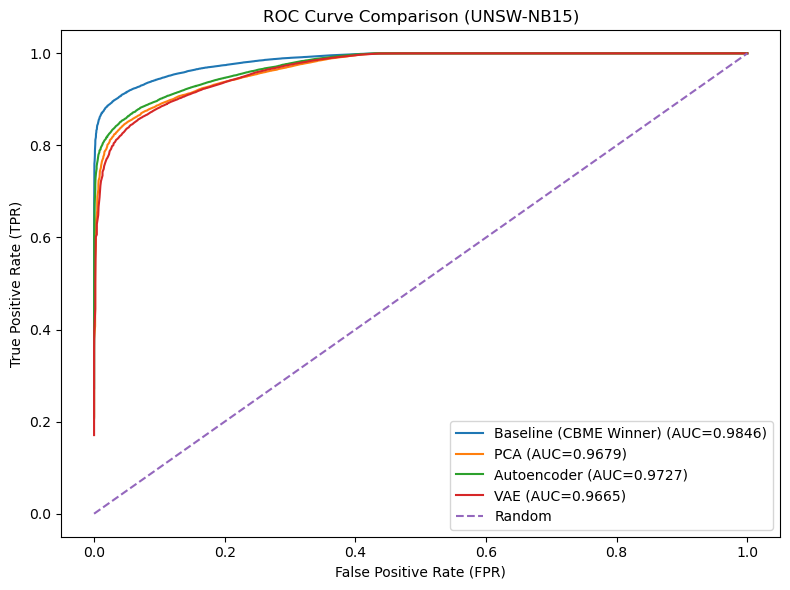

Saved: C:\Users\sohib\Documents\Final Year Project\AutoML\outputs\plots\roc_unsw_comparison.png


In [32]:
import matplotlib.pyplot as plt
import pandas as pd
import h2o

PLOTS_DIR = OUTPUT_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8,6))

for name, model, test_fr in models:
    
    perf = model.model_performance(test_fr)
    
    # FIX: extract ROC correctly for your H2O version
    roc_tuple = perf.roc()
    
    # roc_tuple = (fprs, tprs)
    fpr = roc_tuple[0]
    tpr = roc_tuple[1]
    
    plt.plot(fpr, tpr, label=f"{name} (AUC={perf.auc():.4f})")

# Random baseline
plt.plot([0,1], [0,1], linestyle="--", label="Random")

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve Comparison (UNSW-NB15)")
plt.legend()
plt.tight_layout()

out_path = PLOTS_DIR / "roc_unsw_comparison.png"
plt.savefig(out_path, dpi=200)
plt.show()

print("Saved:", out_path)


---
# Step N3 — Precision–Recall Curve Comparison (UNSW-NB15)

## What we are doing
We generate PR curves manually using predicted probabilities from each model.

## Why we are doing it
Some H2O versions do not expose a PR curve method. Computing PR curves from predictions is standard
and produces the same type of evaluation plot used in research.

## Tools used
- H2O model.predict() to get probabilities
- sklearn.metrics.precision_recall_curve
- matplotlib for plotting

## Output
- outputs/plots/pr_unsw_comparison.png


gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%


C:\Users\sohib\anaconda3\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
C:\Users\sohib\anaconda3\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%


C:\Users\sohib\anaconda3\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
C:\Users\sohib\anaconda3\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%


C:\Users\sohib\anaconda3\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
C:\Users\sohib\anaconda3\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%


C:\Users\sohib\anaconda3\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
C:\Users\sohib\anaconda3\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


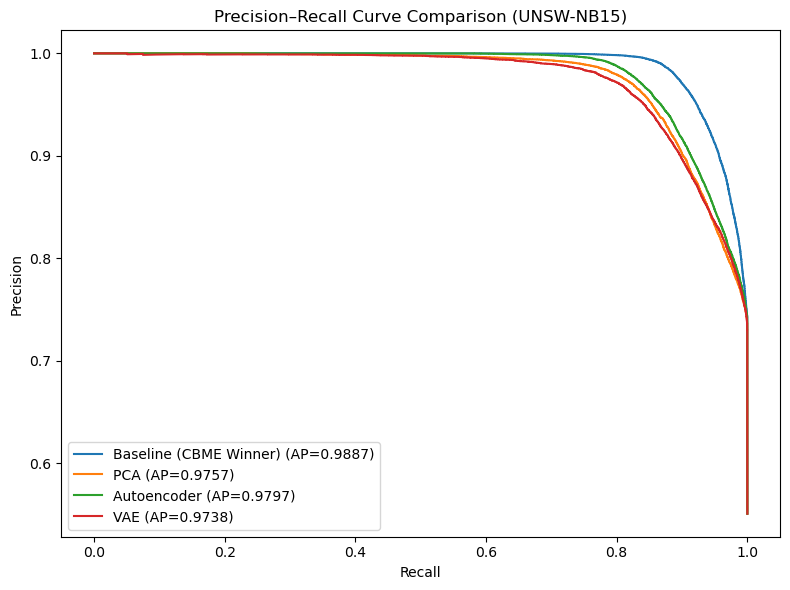

Saved: C:\Users\sohib\Documents\Final Year Project\AutoML\outputs\plots\pr_unsw_comparison.png


In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(8,6))

for name, model, test_fr in models:
    # Predict probabilities
    pred = model.predict(test_fr).as_data_frame()
    
    # H2O prediction output typically: ["predict", "p0", "p1"] or ["predict", "normal", "attack"]
    # For binary factor label {0,1}, the positive class is usually "1"
    # Try common columns:
    prob_col = None
    for c in ["p1", "1", "yes", "true"]:
        if c in pred.columns:
            prob_col = c
            break
    if prob_col is None:
        # fallback: if columns are ["p0","p1"] but named differently, take last column
        prob_col = pred.columns[-1]
    
    y_score = pred[prob_col].values

    # True labels
    y_true = test_fr["label"].as_data_frame().values.ravel().astype(int)

    precision, recall, _ = precision_recall_curve(y_true, y_score)
    ap = average_precision_score(y_true, y_score)

    plt.plot(recall, precision, label=f"{name} (AP={ap:.4f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve Comparison (UNSW-NB15)")
plt.legend()
plt.tight_layout()

out_path = PLOTS_DIR / "pr_unsw_comparison.png"
plt.savefig(out_path, dpi=200)
plt.show()

print("Saved:", out_path)


---
# Step N4.1 — Confusion Matrix (UNSW-NB15 Baseline, Best-F1 Threshold)

## What we are doing
We compute the confusion matrix for the CBME-winning baseline model on UNSW-NB15 test data,
using the automatically selected threshold that maximises F1.

## Why we are doing it
Confusion matrices provide clear counts of:
- True Positives (TP)
- False Positives (FP)
- True Negatives (TN)
- False Negatives (FN)

This is a standard IDS evaluation figure and strengthens the Results chapter.

## Output
- outputs/plots/confusion_unsw_baseline.png
- outputs/metrics/confusion_unsw_baseline.json


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%


C:\Users\sohib\anaconda3\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
C:\Users\sohib\anaconda3\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


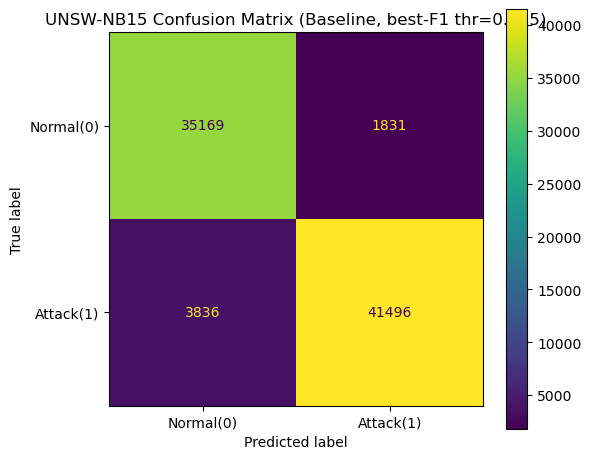

Saved: C:\Users\sohib\Documents\Final Year Project\AutoML\outputs\plots\confusion_unsw_baseline.png
Confusion metrics: {'threshold': 0.875211908812319, 'TN': 35169, 'FP': 1831, 'FN': 3836, 'TP': 41496, 'Accuracy': 0.9311689258125637, 'TPR_Recall': 0.9153798641136504, 'FPR': 0.049486486486486486}


In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import json

# Load UNSW baseline test frame we saved
test_baseline_df = pd.read_parquet(OUTPUT_DIR / "test_frames" / "test_baseline.parquet")
test_baseline_h2o = h2o.H2OFrame(test_baseline_df)
test_baseline_h2o["label"] = test_baseline_h2o["label"].asfactor()

# Get model + best-F1 threshold saved earlier
m_baseline = h2o.get_model(unsw_baseline["leader_model_id"])
thr_unsw = unsw_baseline["best_f1_threshold"]

# Predict probabilities
pred = m_baseline.predict(test_baseline_h2o).as_data_frame()

# Identify probability column for positive class
prob_col = None
for c in ["p1", "1"]:
    if c in pred.columns:
        prob_col = c
        break
if prob_col is None:
    prob_col = pred.columns[-1]

y_score = pred[prob_col].values
y_true = test_baseline_h2o["label"].as_data_frame().values.ravel().astype(int)

# Apply threshold -> predicted labels
y_pred = (y_score >= thr_unsw).astype(int)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=[0,1])
tn, fp, fn, tp = cm.ravel()

# Derived metrics
acc = (tp + tn) / (tp + tn + fp + fn)
tpr = tp / (tp + fn + 1e-12)
fpr = fp / (fp + tn + 1e-12)

cm_info = {
    "threshold": float(thr_unsw),
    "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
    "Accuracy": float(acc),
    "TPR_Recall": float(tpr),
    "FPR": float(fpr)
}

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal(0)","Attack(1)"])
fig, ax = plt.subplots(figsize=(6,5))
disp.plot(ax=ax, values_format="d")
plt.title(f"UNSW-NB15 Confusion Matrix (Baseline, best-F1 thr={thr_unsw:.3f})")
plt.tight_layout()

out_img = PLOTS_DIR / "confusion_unsw_baseline.png"
plt.savefig(out_img, dpi=200)
plt.show()

# Save numbers
with open(OUTPUT_DIR / "metrics" / "confusion_unsw_baseline.json", "w") as f:
    json.dump(cm_info, f, indent=2)

print("Saved:", out_img)
print("Confusion metrics:", cm_info)


---
# Step N4.2 — Confusion Matrix (NSL-KDD Baseline, Best-F1 Threshold)

## What we are doing
We compute the confusion matrix for the NSL-KDD best model using the best-F1 threshold.

## Why we are doing it
It provides interpretable evidence of generalisation performance and false alarms on a second dataset.

## Output
- outputs/plots/confusion_kdd_baseline.png
- outputs/metrics/confusion_kdd_baseline.json


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%


C:\Users\sohib\anaconda3\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
C:\Users\sohib\anaconda3\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


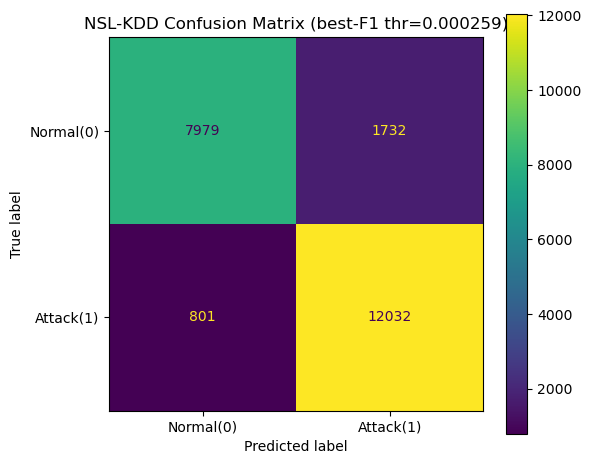

Saved: C:\Users\sohib\Documents\Final Year Project\AutoML\outputs\plots\confusion_kdd_baseline.png
Confusion metrics: {'threshold': 0.00025872856671292513, 'TN': 7979, 'FP': 1732, 'FN': 801, 'TP': 12032, 'Accuracy': 0.8876419446415897, 'TPR_Recall': 0.9375827943582948, 'FPR': 0.17835444341468434}


In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import json

# Rebuild NSL-KDD test frame from saved selected features (so it's reproducible)
# Load NSL-KDD selected features list
with open(OUTPUT_DIR / "features" / "kdd_selected_features.json", "r") as f:
    kdd_selected = json.load(f)

# We need the NSL-KDD selected feature matrix again.
# If you still have X_kdd_test_sel and y_kdd_test in memory, use them; otherwise rebuild from parquet is optional.
try:
    X_kdd_test_sel
    y_kdd_test
except NameError:
    raise NameError("X_kdd_test_sel / y_kdd_test not found in memory. If you want, I’ll give you a rebuild cell.")

test_kdd_df = pd.DataFrame(X_kdd_test_sel, columns=kdd_selected)
test_kdd_df["label"] = np.array(y_kdd_test)

test_kdd_h2o = h2o.H2OFrame(test_kdd_df)
test_kdd_h2o["label"] = test_kdd_h2o["label"].asfactor()

m_kdd = h2o.get_model(kdd["leader_model_id"])
thr_kdd = kdd["best_f1_threshold"]

pred = m_kdd.predict(test_kdd_h2o).as_data_frame()

prob_col = None
for c in ["p1", "1"]:
    if c in pred.columns:
        prob_col = c
        break
if prob_col is None:
    prob_col = pred.columns[-1]

y_score = pred[prob_col].values
y_true = test_kdd_h2o["label"].as_data_frame().values.ravel().astype(int)
y_pred = (y_score >= thr_kdd).astype(int)

cm = confusion_matrix(y_true, y_pred, labels=[0,1])
tn, fp, fn, tp = cm.ravel()

acc = (tp + tn) / (tp + tn + fp + fn)
tpr = tp / (tp + fn + 1e-12)
fpr = fp / (fp + tn + 1e-12)

cm_info = {
    "threshold": float(thr_kdd),
    "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
    "Accuracy": float(acc),
    "TPR_Recall": float(tpr),
    "FPR": float(fpr)
}

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal(0)","Attack(1)"])
fig, ax = plt.subplots(figsize=(6,5))
disp.plot(ax=ax, values_format="d")
plt.title(f"NSL-KDD Confusion Matrix (best-F1 thr={thr_kdd:.6f})")
plt.tight_layout()

out_img = PLOTS_DIR / "confusion_kdd_baseline.png"
plt.savefig(out_img, dpi=200)
plt.show()

with open(OUTPUT_DIR / "metrics" / "confusion_kdd_baseline.json", "w") as f:
    json.dump(cm_info, f, indent=2)

print("Saved:", out_img)
print("Confusion metrics:", cm_info)


---
# Step N5 — Performance Comparison Charts (UNSW-NB15)

## What we are doing
We create bar charts comparing AUC, F1-score, and False Positive Rate across all feature-centric pipelines:
- Baseline MI-selected features (CBME winner)
- PCA latent features
- Autoencoder latent features
- VAE latent features

## Why we are doing it
Bar charts make performance differences easy to interpret and are commonly used in IDS research papers.

## Output
Saved to outputs/plots/:
- perf_auc_unsw.png
- perf_f1_unsw.png
- perf_fpr_unsw.png


,Pipeline,AUC,F1,FPR
0,Baseline,0.984604,0.936498,0.049432
1,PCA,0.967981,0.902377,0.075865
2,Autoencoder,0.972701,0.909273,0.070595
3,VAE,0.966411,0.899415,0.114595


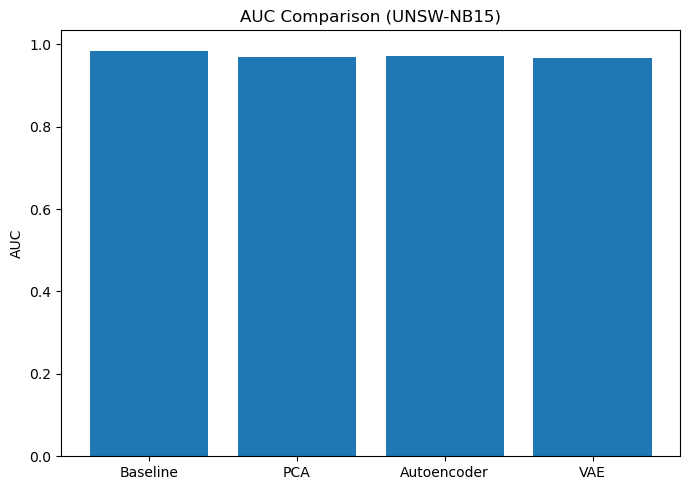

Saved: C:\Users\sohib\Documents\Final Year Project\AutoML\outputs\plots\perf_auc_unsw.png


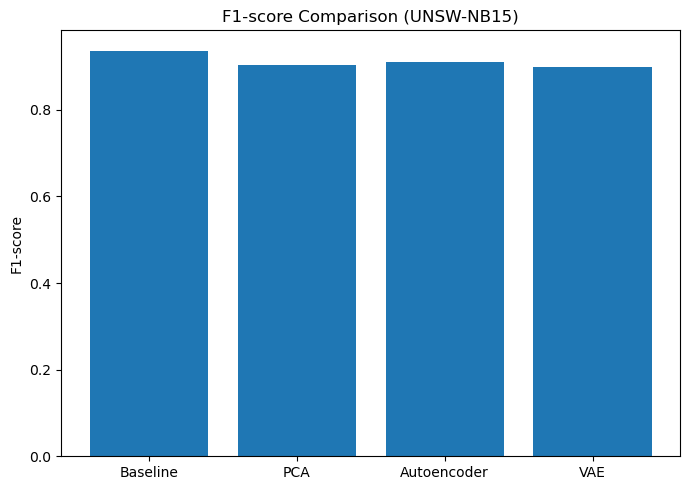

Saved: C:\Users\sohib\Documents\Final Year Project\AutoML\outputs\plots\perf_f1_unsw.png


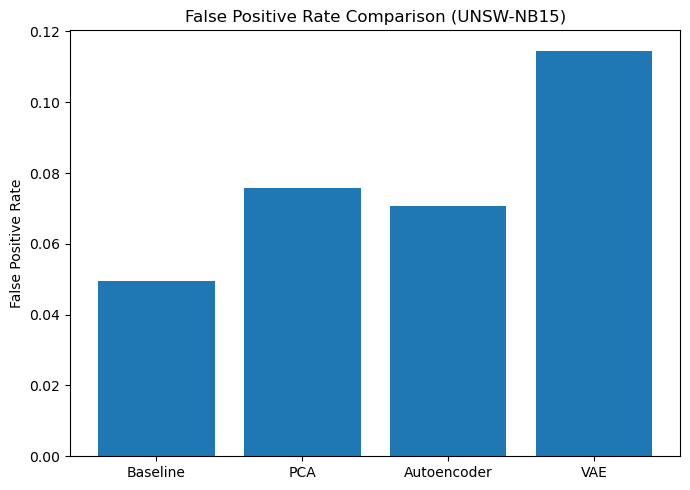

Saved: C:\Users\sohib\Documents\Final Year Project\AutoML\outputs\plots\perf_fpr_unsw.png


In [37]:
import matplotlib.pyplot as plt
import pandas as pd

# Build UNSW comparison table from saved metrics
unsw_comp = pd.DataFrame([
    ("Baseline", unsw_baseline["AUC"], unsw_baseline["F1_at_bestF1"], unsw_baseline["FPR_at_bestF1"]),
    ("PCA", unsw_pca["AUC"], unsw_pca["F1_at_bestF1"], unsw_pca["FPR_at_bestF1"]),
    ("Autoencoder", unsw_ae["AUC"], unsw_ae["F1_at_bestF1"], unsw_ae["FPR_at_bestF1"]),
    ("VAE", unsw_vae["AUC"], unsw_vae["F1_at_bestF1"], unsw_vae["FPR_at_bestF1"]),
], columns=["Pipeline", "AUC", "F1", "FPR"])

display(unsw_comp)

# Plot helper
def bar_plot(metric, filename, ylabel):
    plt.figure(figsize=(7,5))
    plt.bar(unsw_comp["Pipeline"], unsw_comp[metric])
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} Comparison (UNSW-NB15)")
    plt.tight_layout()
    out = OUTPUT_DIR / "plots" / filename
    plt.savefig(out, dpi=200)
    plt.show()
    print("Saved:", out)

bar_plot("AUC", "perf_auc_unsw.png", "AUC")
bar_plot("F1",  "perf_f1_unsw.png",  "F1-score")
bar_plot("FPR", "perf_fpr_unsw.png", "False Positive Rate")


---
# Step N6 — Feature Importance Plot (Baseline CBME Winner)

## What we are doing
We extract and plot the top 20 most important features from the CBME-winning model.

## Why we are doing it
Feature importance explains which network features contribute most to intrusion detection decisions.
This strengthens interpretability and aligns with IDS research practices.

## Output
- outputs/plots/feature_importance_baseline.png
- outputs/features/feature_importance_baseline.csv


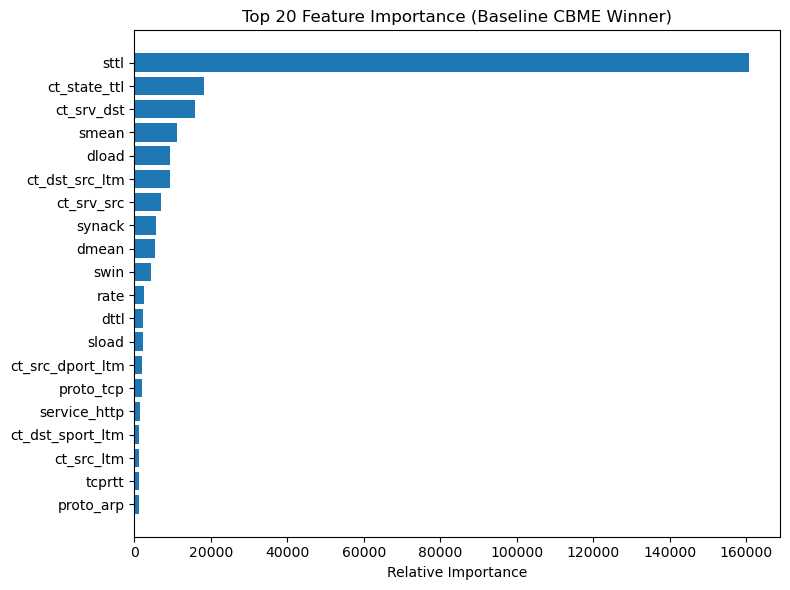

Saved: C:\Users\sohib\Documents\Final Year Project\AutoML\outputs\plots\feature_importance_baseline.png


In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# Load baseline model
model = h2o.get_model(unsw_baseline["leader_model_id"])

# Get variable importance
vi = model.varimp(use_pandas=True)

# Save full table
vi.to_csv(OUTPUT_DIR / "features" / "feature_importance_baseline.csv", index=False)

# Top 20
vi_top = vi.head(20)

# Plot
plt.figure(figsize=(8,6))
plt.barh(vi_top["variable"][::-1], vi_top["relative_importance"][::-1])
plt.xlabel("Relative Importance")
plt.title("Top 20 Feature Importance (Baseline CBME Winner)")
plt.tight_layout()

out = OUTPUT_DIR / "plots" / "feature_importance_baseline.png"
plt.savefig(out, dpi=200)
plt.show()

print("Saved:", out)


---
# Step N7 — Mutual Information Ranking Plot

## What we are doing
We visualise the mutual information ranking of features and cumulative contribution.

## Why we are doing it
This demonstrates automated feature selection effectiveness and aligns with research literature.

## Output
- outputs/plots/mi_ranking_curve.png


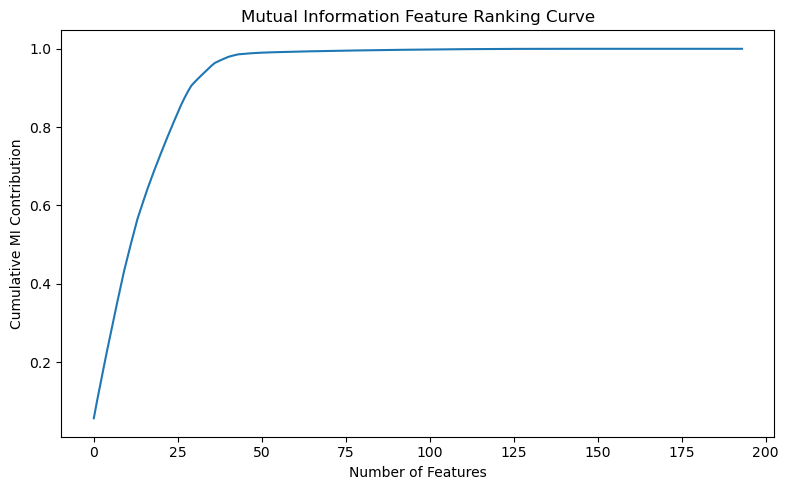

Saved: C:\Users\sohib\Documents\Final Year Project\AutoML\outputs\plots\mi_ranking_curve.png


In [39]:
import pandas as pd
import matplotlib.pyplot as plt

# Load MI ranking from UNSW pipeline
mi_df = pd.read_csv(OUTPUT_DIR / "features" / "mutual_information_ranking.csv")

mi_df["cumulative"] = mi_df["mi_score"].cumsum()
mi_df["cumulative_norm"] = mi_df["cumulative"] / mi_df["cumulative"].max()

plt.figure(figsize=(8,5))
plt.plot(range(len(mi_df)), mi_df["cumulative_norm"])
plt.xlabel("Number of Features")
plt.ylabel("Cumulative MI Contribution")
plt.title("Mutual Information Feature Ranking Curve")
plt.tight_layout()

out = OUTPUT_DIR / "plots" / "mi_ranking_curve.png"
plt.savefig(out, dpi=200)
plt.show()

print("Saved:", out)


---
# Step N8 — ROC and PR Curves (NSL-KDD)

## What we are doing
We plot ROC and Precision–Recall curves for the NSL-KDD best AutoML model.

## Why we are doing it
Including evaluation plots for the second dataset strengthens cross-dataset validation and makes the Results section look more like a research paper.

## Output
- outputs/plots/roc_kdd_best.png
- outputs/plots/pr_kdd_best.png


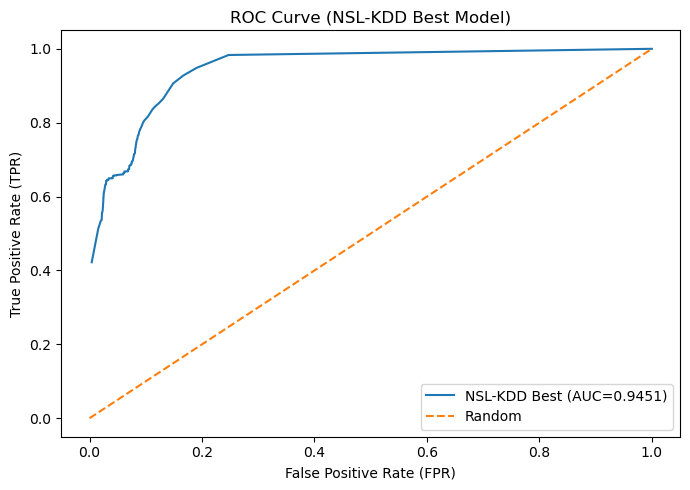

Saved: C:\Users\sohib\Documents\Final Year Project\AutoML\outputs\plots\roc_kdd_best.png
gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%


C:\Users\sohib\anaconda3\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
C:\Users\sohib\anaconda3\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


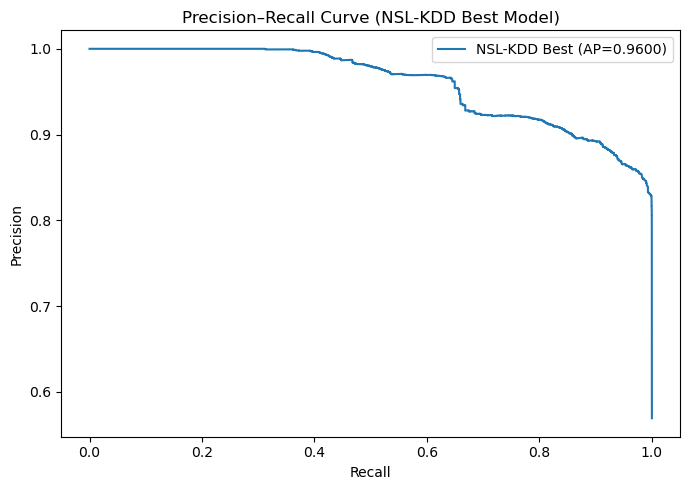

Saved: C:\Users\sohib\Documents\Final Year Project\AutoML\outputs\plots\pr_kdd_best.png


In [40]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# Build NSL-KDD test H2OFrame again (you already did this for confusion matrix)
# If test_kdd_h2o exists, reuse it; otherwise rebuild quickly.
try:
    test_kdd_h2o
except NameError:
    import json, pandas as pd
    with open(OUTPUT_DIR / "features" / "kdd_selected_features.json", "r") as f:
        kdd_selected = json.load(f)
    test_kdd_df = pd.DataFrame(X_kdd_test_sel, columns=kdd_selected)
    test_kdd_df["label"] = np.array(y_kdd_test)
    test_kdd_h2o = h2o.H2OFrame(test_kdd_df)
    test_kdd_h2o["label"] = test_kdd_h2o["label"].asfactor()

m_kdd = h2o.get_model(kdd["leader_model_id"])
perf_kdd = m_kdd.model_performance(test_kdd_h2o)

# --- ROC ---
roc_tuple = perf_kdd.roc()
fpr, tpr = roc_tuple[0], roc_tuple[1]

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"NSL-KDD Best (AUC={perf_kdd.auc():.4f})")
plt.plot([0,1],[0,1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve (NSL-KDD Best Model)")
plt.legend()
plt.tight_layout()
out = OUTPUT_DIR / "plots" / "roc_kdd_best.png"
plt.savefig(out, dpi=200)
plt.show()
print("Saved:", out)

# --- PR (manual from predictions; your H2O lacks pr_curve()) ---
pred = m_kdd.predict(test_kdd_h2o).as_data_frame()
prob_col = "p1" if "p1" in pred.columns else pred.columns[-1]
y_score = pred[prob_col].values
y_true = test_kdd_h2o["label"].as_data_frame().values.ravel().astype(int)

precision, recall, _ = precision_recall_curve(y_true, y_score)
ap = average_precision_score(y_true, y_score)

plt.figure(figsize=(7,5))
plt.plot(recall, precision, label=f"NSL-KDD Best (AP={ap:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (NSL-KDD Best Model)")
plt.legend()
plt.tight_layout()
out = OUTPUT_DIR / "plots" / "pr_kdd_best.png"
plt.savefig(out, dpi=200)
plt.show()
print("Saved:", out)


---
# Step N9 — H2O AutoML Model Selection Charts (Leaderboard)

## What we are doing
We visualise the AutoML leaderboard to show the model selection process:
- which algorithms were trained (GBM/DRF/GLM/DeepLearning/Ensembles)
- their AUC/logloss scores
- the final selected leader

## Why we are doing it
This provides transparency and justifies why a specific model was chosen automatically.
It is a common figure/table in AutoML research papers.

## Output
Saved to outputs/plots/:
- automl_leaderboard_unsw_top10.png
- automl_leaderboard_kdd_top10.png


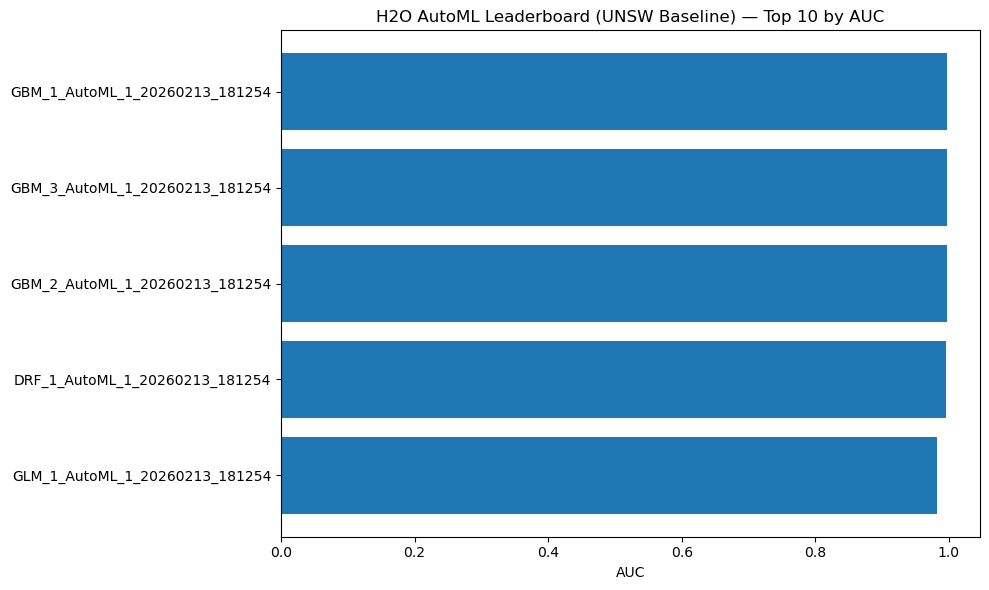

Saved: C:\Users\sohib\Documents\Final Year Project\AutoML\outputs\plots\automl_leaderboard_unsw_top10.png


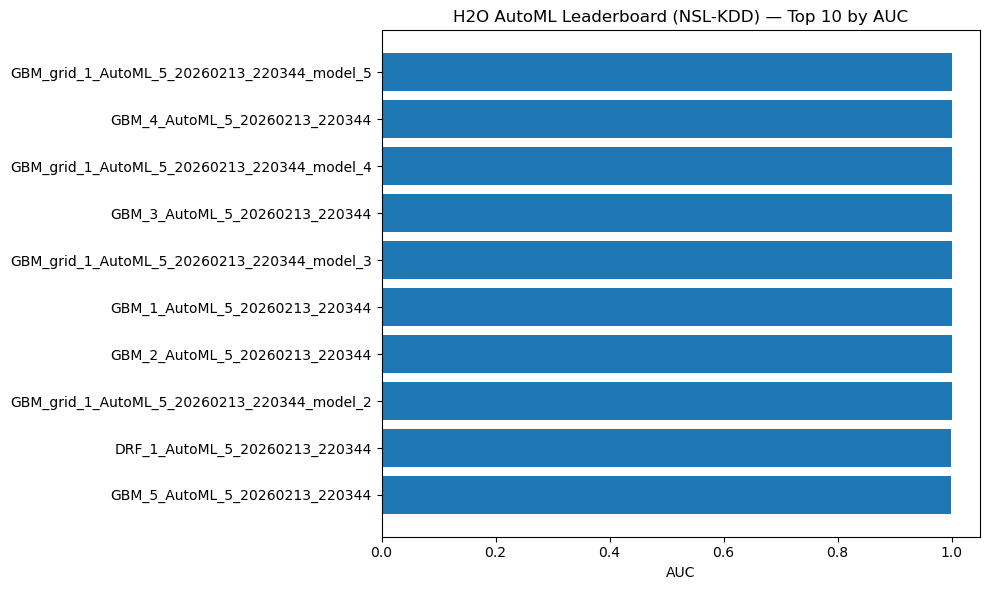

Saved: C:\Users\sohib\Documents\Final Year Project\AutoML\outputs\plots\automl_leaderboard_kdd_top10.png


In [41]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_leaderboard(csv_path, title, out_name, metric="auc", top_n=10):
    lb = pd.read_csv(csv_path)
    # Ensure metric exists
    if metric not in lb.columns:
        raise ValueError(f"Metric '{metric}' not found in {csv_path}. Available: {list(lb.columns)}")

    top = lb.sort_values(metric, ascending=False).head(top_n).copy()
    top = top.iloc[::-1]  # reverse for nicer horizontal chart

    plt.figure(figsize=(10, 6))
    plt.barh(top["model_id"], top[metric])
    plt.xlabel(metric.upper())
    plt.title(title)
    plt.tight_layout()

    out = OUTPUT_DIR / "plots" / out_name
    plt.savefig(out, dpi=200)
    plt.show()
    print("Saved:", out)

# UNSW baseline leaderboard (from Step F)
plot_leaderboard(
    csv_path=OUTPUT_DIR / "leaderboards" / "automl_leaderboard.csv",
    title="H2O AutoML Leaderboard (UNSW Baseline) — Top 10 by AUC",
    out_name="automl_leaderboard_unsw_top10.png",
    metric="auc",
    top_n=10
)

# NSL-KDD leaderboard (from Step M.4)
plot_leaderboard(
    csv_path=OUTPUT_DIR / "leaderboards" / "automl_leaderboard_kdd.csv",
    title="H2O AutoML Leaderboard (NSL-KDD) — Top 10 by AUC",
    out_name="automl_leaderboard_kdd_top10.png",
    metric="auc",
    top_n=10
)


---
# Step N9.2 — AutoML Search Summary (Models per Algorithm)

## What we are doing
We parse model_id strings to estimate how many models AutoML trained per algorithm family.

## Why we are doing it
This provides an at-a-glance summary of the AutoML search behaviour and strengthens the methodology/results narrative.

## Output
- outputs/plots/automl_model_counts_unsw.png
- outputs/plots/automl_model_counts_kdd.png


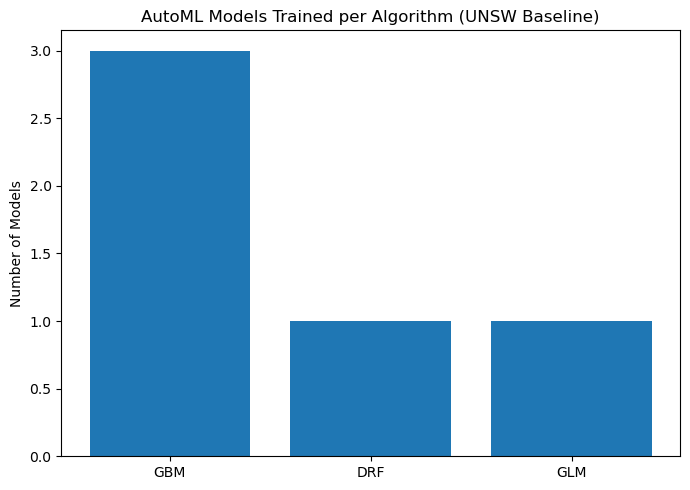

Saved: C:\Users\sohib\Documents\Final Year Project\AutoML\outputs\plots\automl_model_counts_unsw.png


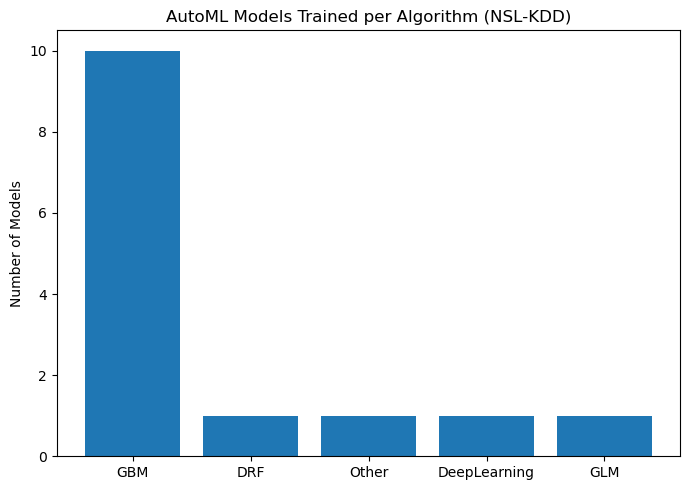

Saved: C:\Users\sohib\Documents\Final Year Project\AutoML\outputs\plots\automl_model_counts_kdd.png


In [42]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_model_counts(csv_path, title, out_name):
    lb = pd.read_csv(csv_path)

    def algo_from_id(mid: str):
        # Common prefixes: GBM_, DRF_, GLM_, DeepLearning_, StackedEnsemble_, XGBoost_
        for a in ["StackedEnsemble", "GBM", "DRF", "GLM", "DeepLearning", "XGBoost"]:
            if str(mid).startswith(a):
                return a
        # grids usually include algo name too
        for a in ["GBM", "DRF", "GLM", "DeepLearning", "XGBoost"]:
            if a in str(mid):
                return a
        return "Other"

    lb["algo"] = lb["model_id"].apply(algo_from_id)
    counts = lb["algo"].value_counts()

    plt.figure(figsize=(7,5))
    plt.bar(counts.index, counts.values)
    plt.ylabel("Number of Models")
    plt.title(title)
    plt.tight_layout()

    out = OUTPUT_DIR / "plots" / out_name
    plt.savefig(out, dpi=200)
    plt.show()
    print("Saved:", out)

plot_model_counts(
    OUTPUT_DIR / "leaderboards" / "automl_leaderboard.csv",
    "AutoML Models Trained per Algorithm (UNSW Baseline)",
    "automl_model_counts_unsw.png"
)

plot_model_counts(
    OUTPUT_DIR / "leaderboards" / "automl_leaderboard_kdd.csv",
    "AutoML Models Trained per Algorithm (NSL-KDD)",
    "automl_model_counts_kdd.png"
)


---
# Save NSL-KDD Test Frame (for Results Notebook)

We save the NSL-KDD test feature matrix used for evaluation so that the Results notebook can load it
without rebuilding preprocessing/feature selection.


In [43]:
import pandas as pd
import numpy as np
import json

TEST_FRAMES_DIR = OUTPUT_DIR / "test_frames"
TEST_FRAMES_DIR.mkdir(parents=True, exist_ok=True)

# Load selected feature names (so columns match)
with open(OUTPUT_DIR / "features" / "kdd_selected_features.json", "r") as f:
    kdd_selected = json.load(f)

test_kdd_df = pd.DataFrame(X_kdd_test_sel, columns=kdd_selected)
test_kdd_df["label"] = np.array(y_kdd_test)

out_path = TEST_FRAMES_DIR / "test_kdd.parquet"
test_kdd_df.to_parquet(out_path)

print("✅ Saved:", out_path)
print("Shape:", test_kdd_df.shape)


✅ Saved: C:\Users\sohib\Documents\Final Year Project\AutoML\outputs\test_frames\test_kdd.parquet
Shape: (22544, 62)
